# Breast Cancer Recurrence Classification
## Machine Learning Analysis of the Wisconsin Prognostic Breast Cancer (WPBC) Dataset

**Dataset:** Wisconsin Prognostic Breast Cancer (WPBC) — UCI Machine Learning Repository  
**Donor:** Dr. William H. Wolberg, University of Wisconsin (December 1995)  
**Task:** Binary classification — predict whether breast cancer *recurs* (R) or *does not recur* (N)

### Dataset Overview
- **198 patient records**, **35 columns** (ID, outcome, follow-up time, 30 cell nucleus features, tumor size, lymph node status)
- Features are computed from Fine Needle Aspirate (FNA) digital images
- For each of 10 base measurements the dataset provides **mean**, **standard error (SE)**, and **worst** (largest) values
- Class distribution: 151 Non-Recurrence (N, 76.3%) / 47 Recurrence (R, 23.7%)

### Pipeline Overview
1. Exploratory Data Analysis (EDA)
2. Preprocessing: missing value imputation → data leakage prevention → StandardScaler → SMOTE → ANOVA feature selection
3. Baseline training of 6 classifiers with 5-fold cross-validation
4. Hyperparameter optimization via GridSearchCV
5. Overfitting analysis and model comparison

---
## 1. Setup & Imports

In [1]:
# Core data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Imbalanced data
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Data Loading

The WPBC dataset has no header row. Column names are assigned manually according to the UCI documentation.

In [2]:
# Define column names
# 10 base nucleus features, each with mean / SE / worst variants
base_features = [
    'radius', 'texture', 'perimeter', 'area', 'smoothness',
    'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension'
]

suffixes = ['_mean', '_se', '_worst']
feature_columns = [f"{feat}{suf}" for suf in suffixes for feat in base_features]

column_names = ['id', 'outcome', 'time'] + feature_columns + ['tumor_size', 'lymph_node_status']

print(f"Total columns: {len(column_names)}")
print(f"Feature columns: {len(feature_columns)} nucleus measurements + tumor_size + lymph_node_status")

Total columns: 35
Feature columns: 30 nucleus measurements + tumor_size + lymph_node_status


In [3]:
# Load dataset — missing values are encoded as '?'
df = pd.read_csv(
    'data/wpbc.data',
    header=None,
    names=column_names,
    na_values='?'
)

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset shape: 198 rows × 35 columns

First 3 rows:


,id,outcome,time,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,tumor_size,lymph_node_status
0,119513,N,31,18.02,27.60,117.5,1013.0,0.09489,0.1036,0.1086,...,139.7,1436.0,0.1195,0.1926,0.3140,0.1170,0.2677,0.08113,5.0,5.0
1,8423,N,61,17.99,10.38,122.8,1001.0,0.11840,0.2776,0.3001,...,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,3.0,2.0
2,842517,N,116,21.37,17.44,137.5,1373.0,0.08836,0.1189,0.1255,...,159.1,1949.0,0.1188,0.3449,0.3414,0.2032,0.4334,0.09067,2.5,0.0


---
## 3. Exploratory Data Analysis

### 3.1 General Overview

In [4]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nRows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"\nData types:")
print(df.dtypes.value_counts())
print("\n" + "=" * 60)
df.info()

DATASET OVERVIEW

Rows    : 198
Columns : 35

Data types:
float64    32
int64       2
object      1
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       198 non-null    int64  
 1   outcome                  198 non-null    object 
 2   time                     198 non-null    int64  
 3   radius_mean              198 non-null    float64
 4   texture_mean             198 non-null    float64
 5   perimeter_mean           198 non-null    float64
 6   area_mean                198 non-null    float64
 7   smoothness_mean          198 non-null    float64
 8   compactness_mean         198 non-null    float64
 9   concavity_mean           198 non-null    float64
 10  concave_points_mean      198 non-null    float64
 11  symmetry_mean            198 non-null    float64
 12  fractal

In [5]:
# Statistical summary
print("Statistical Summary (numeric columns):")
df.describe().T.round(3)

Statistical Summary (numeric columns):


,count,mean,std,min,25%,50%,75%,max
id,198.0,1990468.818,2889025.293,8423.000,855745.250,886339.000,927995.750,9411300.000
time,198.0,46.732,34.463,1.000,14.000,39.500,72.750,125.000
radius_mean,198.0,17.412,3.162,10.950,15.052,17.290,19.580,27.220
texture_mean,198.0,22.276,4.298,10.380,19.412,21.750,24.655,39.280
perimeter_mean,198.0,114.857,21.383,71.900,98.160,113.700,129.650,182.100
area_mean,198.0,970.041,352.149,361.600,702.525,929.100,1193.500,2250.000
smoothness_mean,198.0,0.103,0.013,0.075,0.094,0.102,0.111,0.145
compactness_mean,198.0,0.143,0.050,0.046,0.110,0.132,0.172,0.311
concavity_mean,198.0,0.156,0.071,0.024,0.107,0.151,0.200,0.427
concave_points_mean,198.0,0.087,0.034,0.020,0.064,0.086,0.104,0.201


**Observations:**
- There are large **scale differences** across features (e.g., `area_mean` is in the hundreds while `smoothness_mean` is a decimal). StandardScaler normalization is required.
- Large min/max gaps indicate **outliers**, especially in area and perimeter features.
- `lymph_node_status` shows missing values (confirmed via `info()`).

### 3.2 Missing Value Analysis

In [6]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage (%)': missing_percent
})

missing_with_values = missing_df[missing_df['Missing Count'] > 0]

if len(missing_with_values) > 0:
    print("Columns with missing values:")
    print(missing_with_values)
    print(f"\nTotal missing values: {df.isnull().sum().sum()}")
else:
    print("No missing values found.")

Columns with missing values:
                   Missing Count  Percentage (%)
lymph_node_status              4            2.02

Total missing values: 4


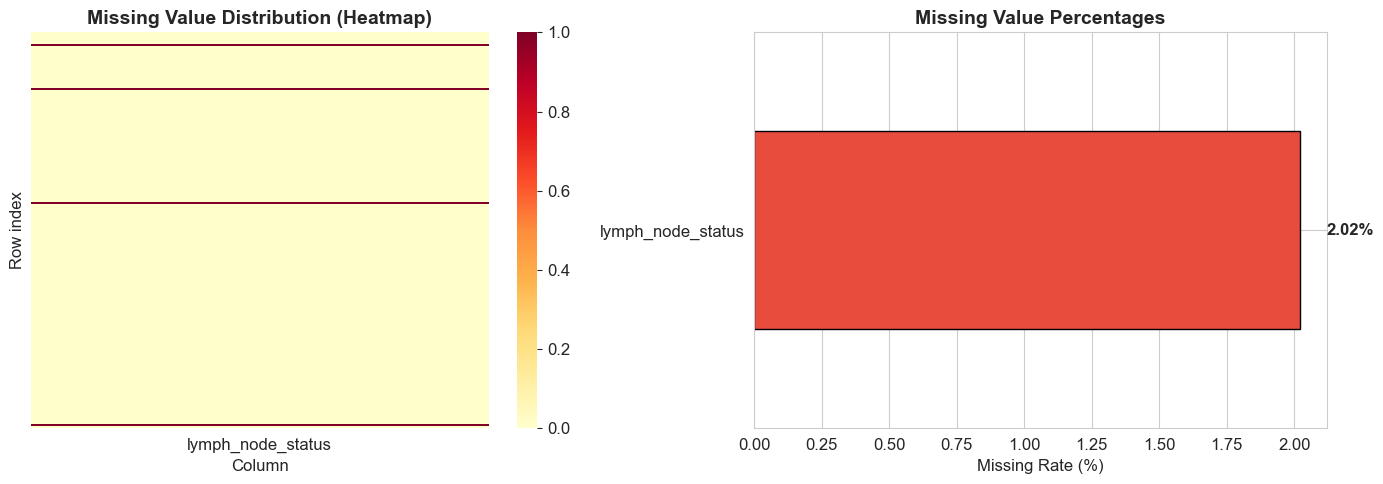

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing value heatmap
cols_with_missing = df.columns[df.isnull().any()].tolist()
if cols_with_missing:
    sns.heatmap(df[cols_with_missing].isnull(), cbar=True, yticklabels=False,
                cmap='YlOrRd', ax=axes[0])
    axes[0].set_title('Missing Value Distribution (Heatmap)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Column')
    axes[0].set_ylabel('Row index')
else:
    axes[0].text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=14)
    axes[0].set_title('Missing Value Distribution', fontsize=14, fontweight='bold')

# Missing percentage bar chart
if len(missing_with_values) > 0:
    missing_with_values['Percentage (%)'].plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black')
    axes[1].set_title('Missing Value Percentages', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Missing Rate (%)')
    for i, v in enumerate(missing_with_values['Percentage (%)']):
        axes[1].text(v + 0.1, i, f'{v}%', va='center', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

In [8]:
# Impute missing values with the column median
# Median is preferred over mean because it is robust to outliers
if df['lymph_node_status'].isnull().sum() > 0:
    median_val = df['lymph_node_status'].median()
    df['lymph_node_status'].fillna(median_val, inplace=True)
    print(f"'lymph_node_status': {df['lymph_node_status'].isnull().sum() + 4} missing values imputed with median ({median_val}).")

print(f"Remaining missing values: {df.isnull().sum().sum()}")

'lymph_node_status': 4 missing values imputed with median (1.0).
Remaining missing values: 0


### 3.3 Class Distribution

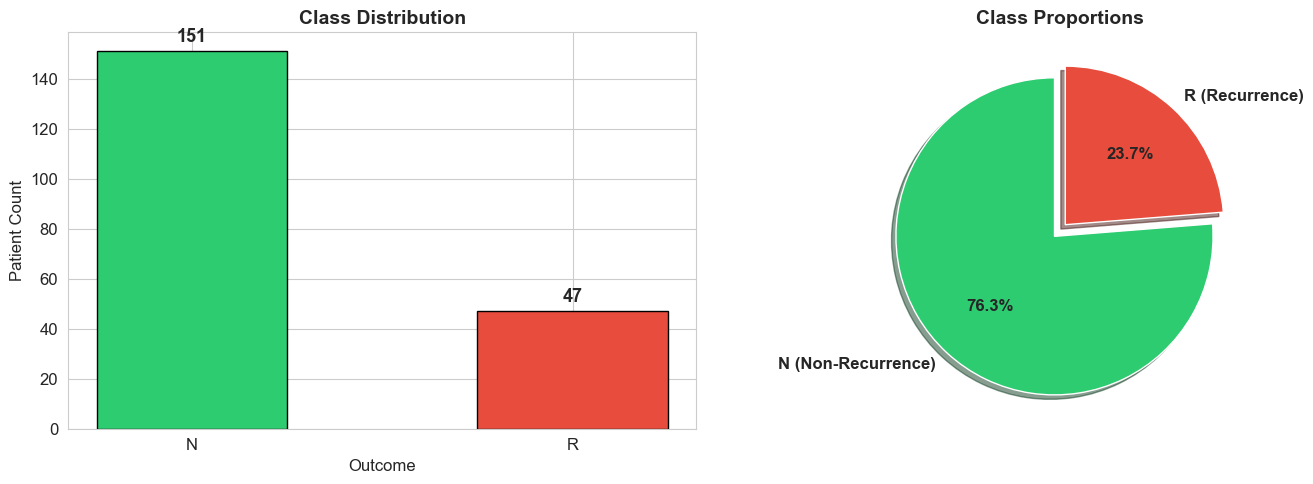

Non-Recurrence (N): 151 (76.3%)
Recurrence    (R): 47 (23.7%)
Imbalance ratio (N:R): 3.21:1


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

outcome_counts = df['outcome'].value_counts()
colors = ['#2ecc71', '#e74c3c']

# Bar chart
bars = axes[0].bar(outcome_counts.index, outcome_counts.values,
                   color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Patient Count')
for bar, count in zip(bars, outcome_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=13)

# Pie chart
axes[1].pie(outcome_counts.values,
            labels=['N (Non-Recurrence)', 'R (Recurrence)'],
            autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0.05),
            textprops={'fontsize': 12, 'fontweight': 'bold'}, shadow=True)
axes[1].set_title('Class Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Non-Recurrence (N): {outcome_counts.get('N', 0)} ({outcome_counts.get('N', 0)/len(df)*100:.1f}%)")
print(f"Recurrence    (R): {outcome_counts.get('R', 0)} ({outcome_counts.get('R', 0)/len(df)*100:.1f}%)")
print(f"Imbalance ratio (N:R): {outcome_counts.get('N', 0)/outcome_counts.get('R', 1):.2f}:1")

**Key observation:** The dataset is **significantly imbalanced** (~3:1 ratio). Standard classifiers tend to be biased toward the majority class (N). SMOTE will be applied to the training set to address this.

### 3.4 Feature Distributions by Class

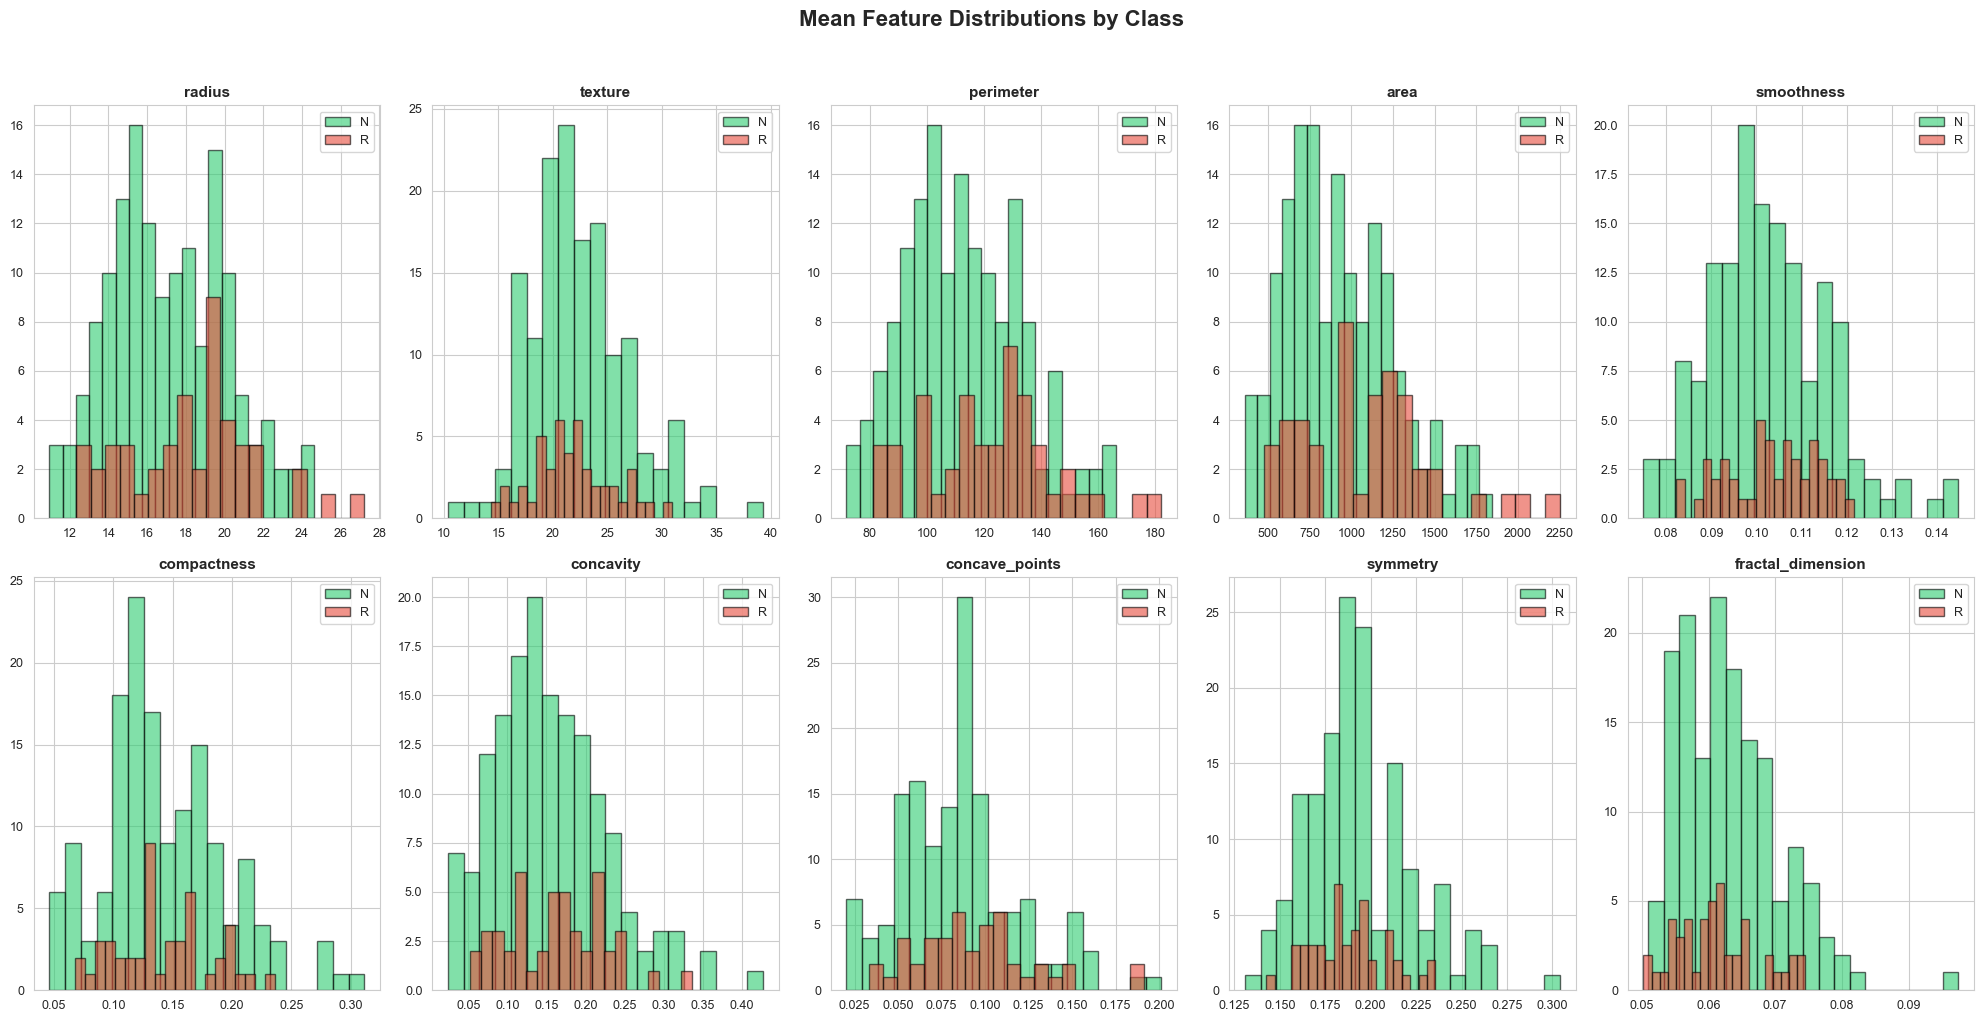

In [10]:
# Mean features distribution
mean_features = [col for col in df.columns if '_mean' in col]

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('Mean Feature Distributions by Class', fontsize=16, fontweight='bold', y=1.02)

for idx, feature in enumerate(mean_features):
    row, col = idx // 5, idx % 5
    ax = axes[row][col]
    for label, color in zip(['N', 'R'], ['#2ecc71', '#e74c3c']):
        subset = df[df['outcome'] == label][feature]
        ax.hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='black')
    ax.set_title(feature.replace('_mean', ''), fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

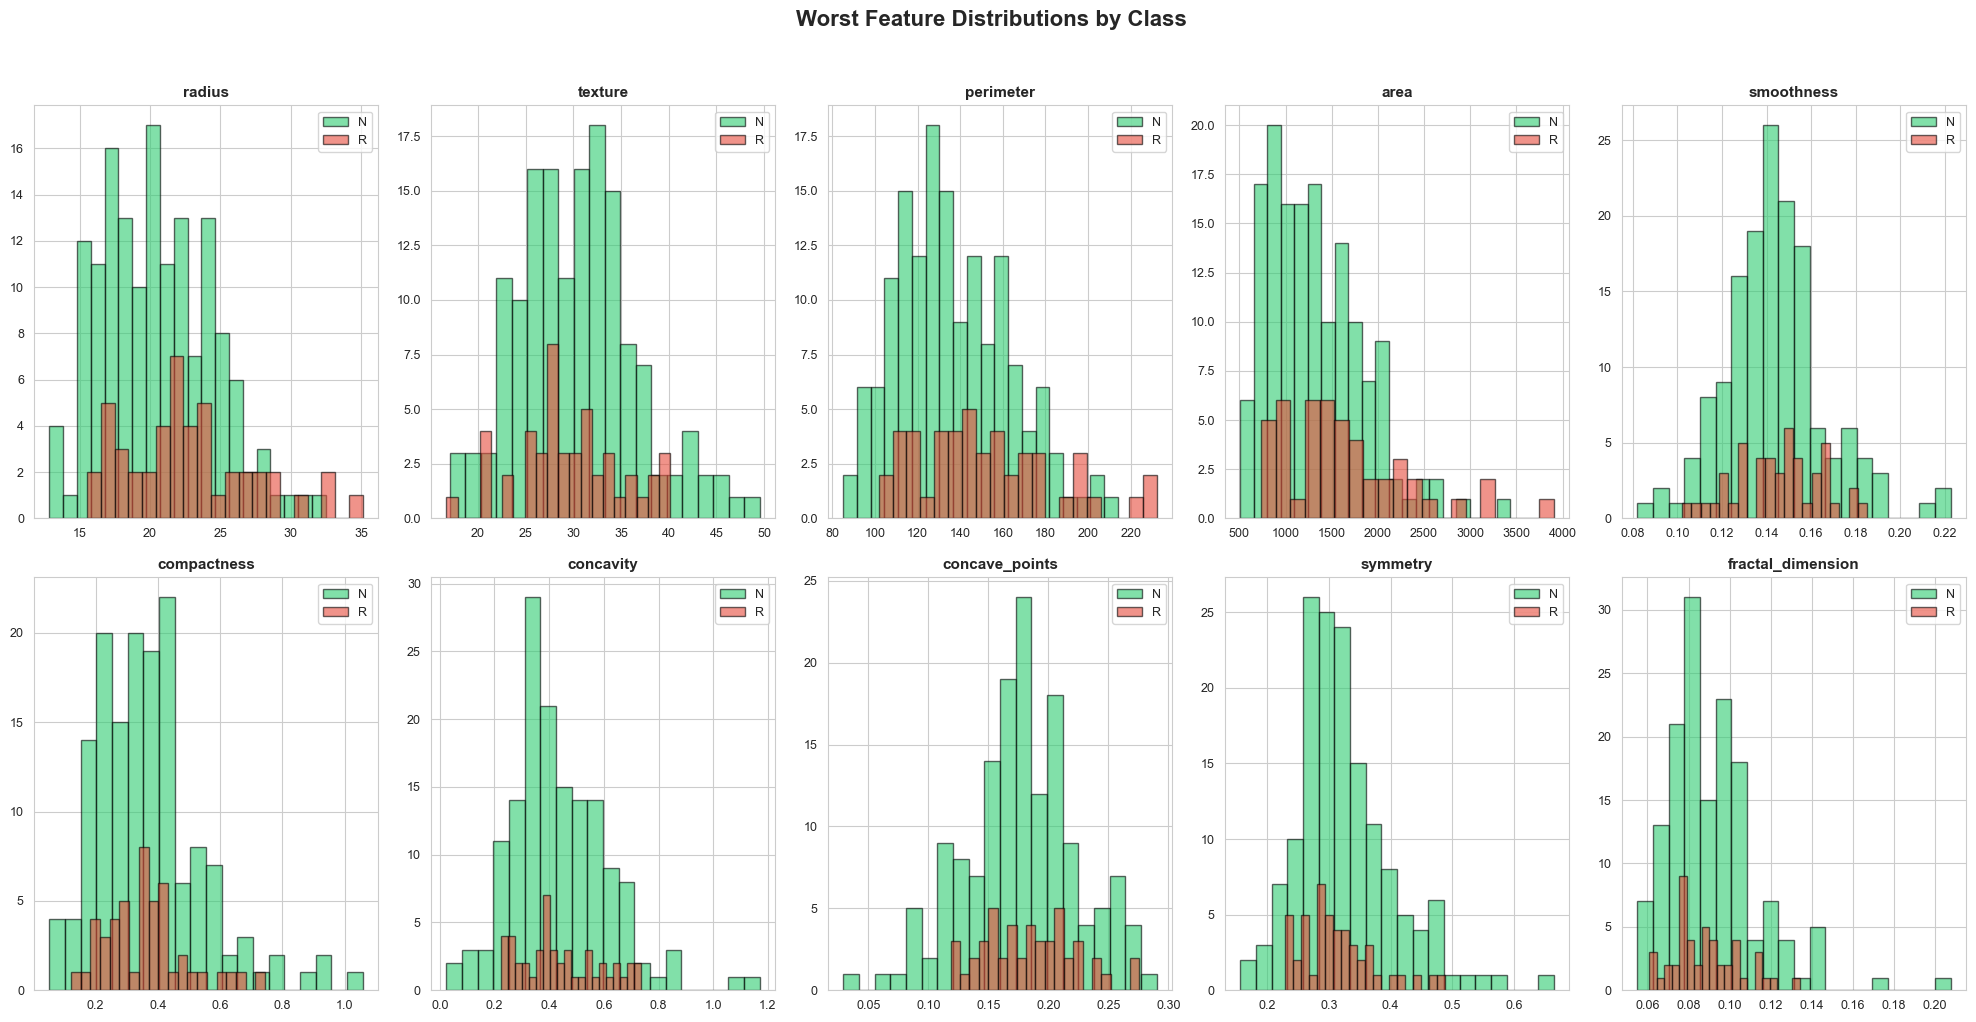

In [11]:
# Worst features distribution
worst_features = [col for col in df.columns if '_worst' in col]

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('Worst Feature Distributions by Class', fontsize=16, fontweight='bold', y=1.02)

for idx, feature in enumerate(worst_features):
    row, col = idx // 5, idx % 5
    ax = axes[row][col]
    for label, color in zip(['N', 'R'], ['#2ecc71', '#e74c3c']):
        subset = df[df['outcome'] == label][feature]
        ax.hist(subset, bins=20, alpha=0.6, label=label, color=color, edgecolor='black')
    ax.set_title(feature.replace('_worst', ''), fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

**Observations:**
- **Radius, perimeter, area** features tend to be higher in recurrence (R) patients, suggesting larger tumors correlate with recurrence risk.
- **Concavity and concave_points** show clear class separation — recurrence cases show higher values.
- Many features exhibit **right-skewed distributions**, especially size-related measurements.

### 3.5 Box Plots & Outlier Analysis

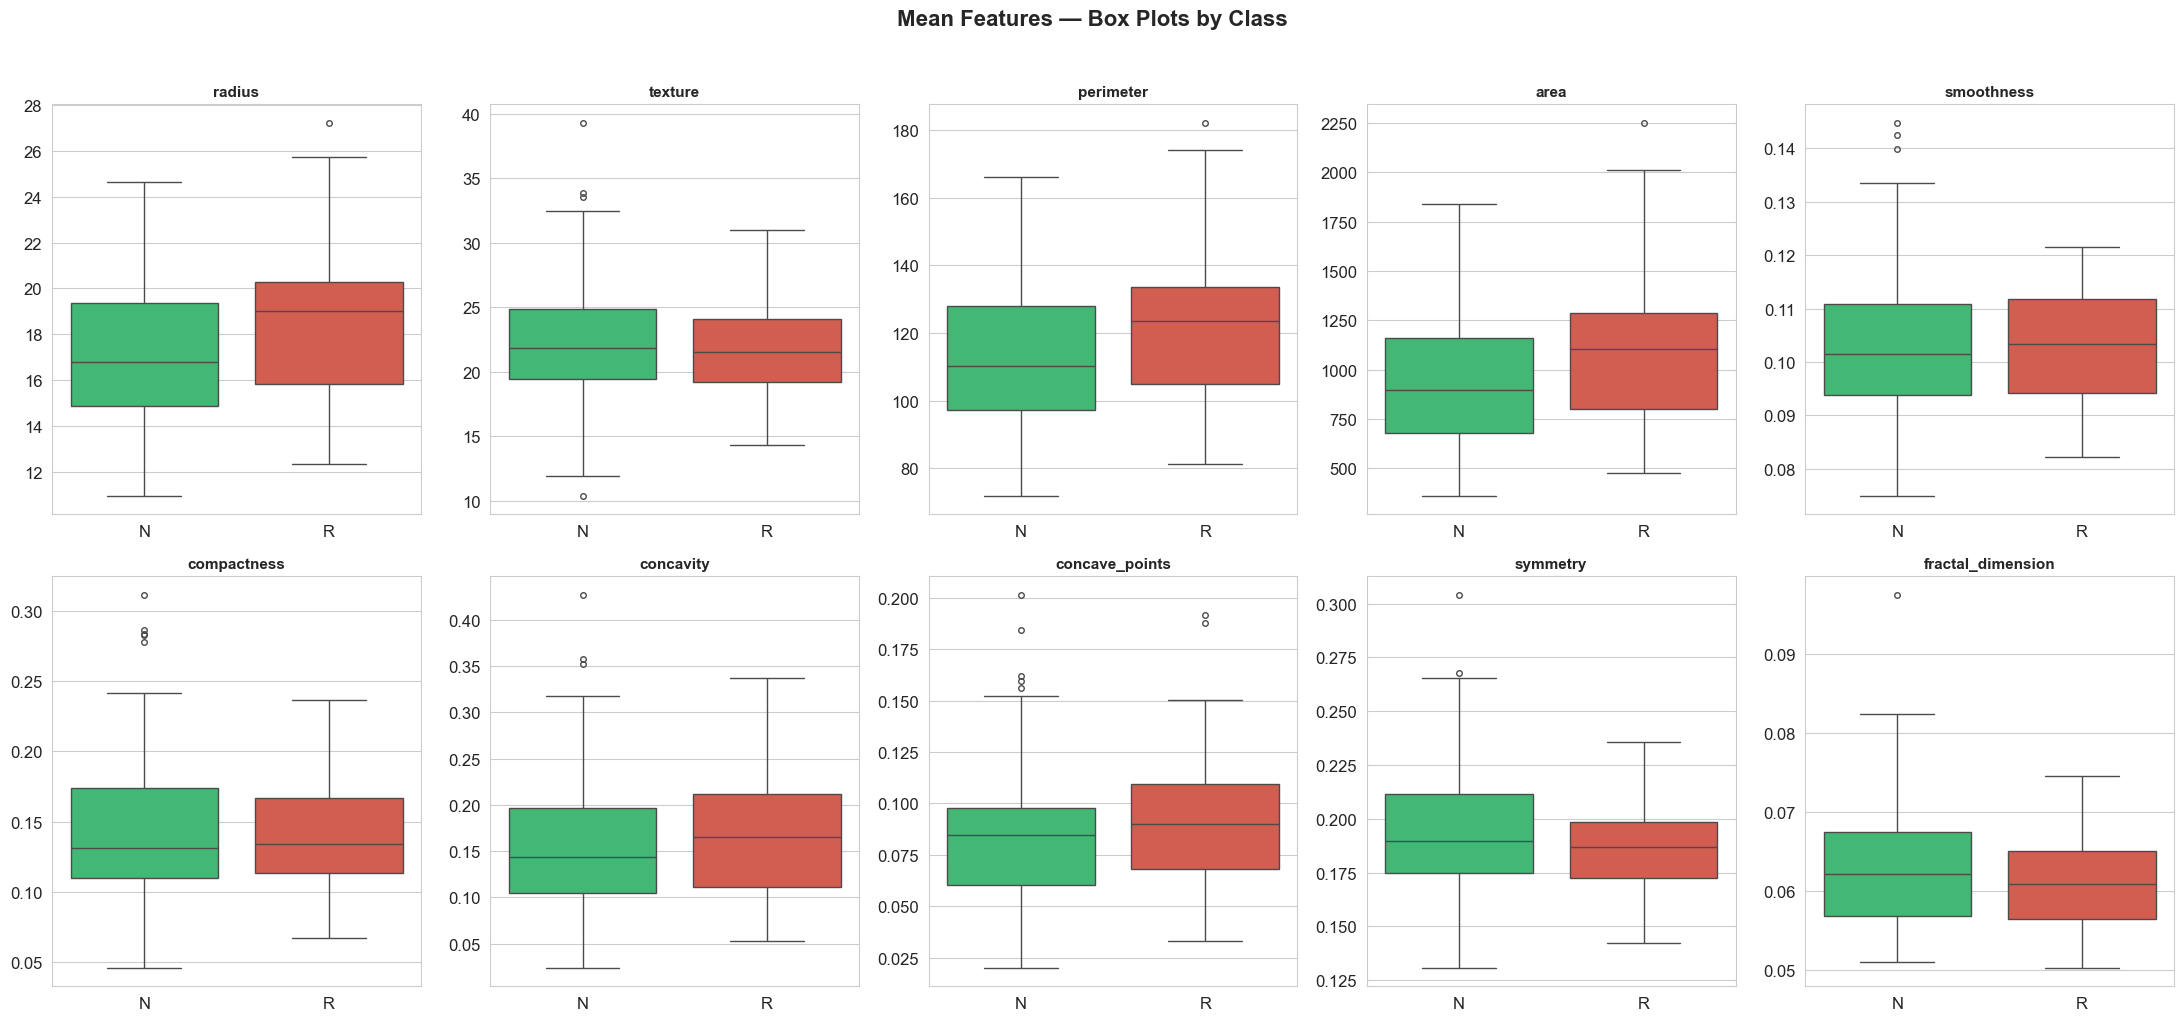

In [12]:
# Box plots for mean features
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.suptitle('Mean Features — Box Plots by Class', fontsize=16, fontweight='bold', y=1.02)

for idx, feature in enumerate(mean_features):
    row, col = idx // 5, idx % 5
    ax = axes[row][col]
    sns.boxplot(x='outcome', y=feature, data=df, ax=ax,
                palette={'N': '#2ecc71', 'R': '#e74c3c'},
                flierprops=dict(marker='o', markersize=4))
    ax.set_title(feature.replace('_mean', ''), fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

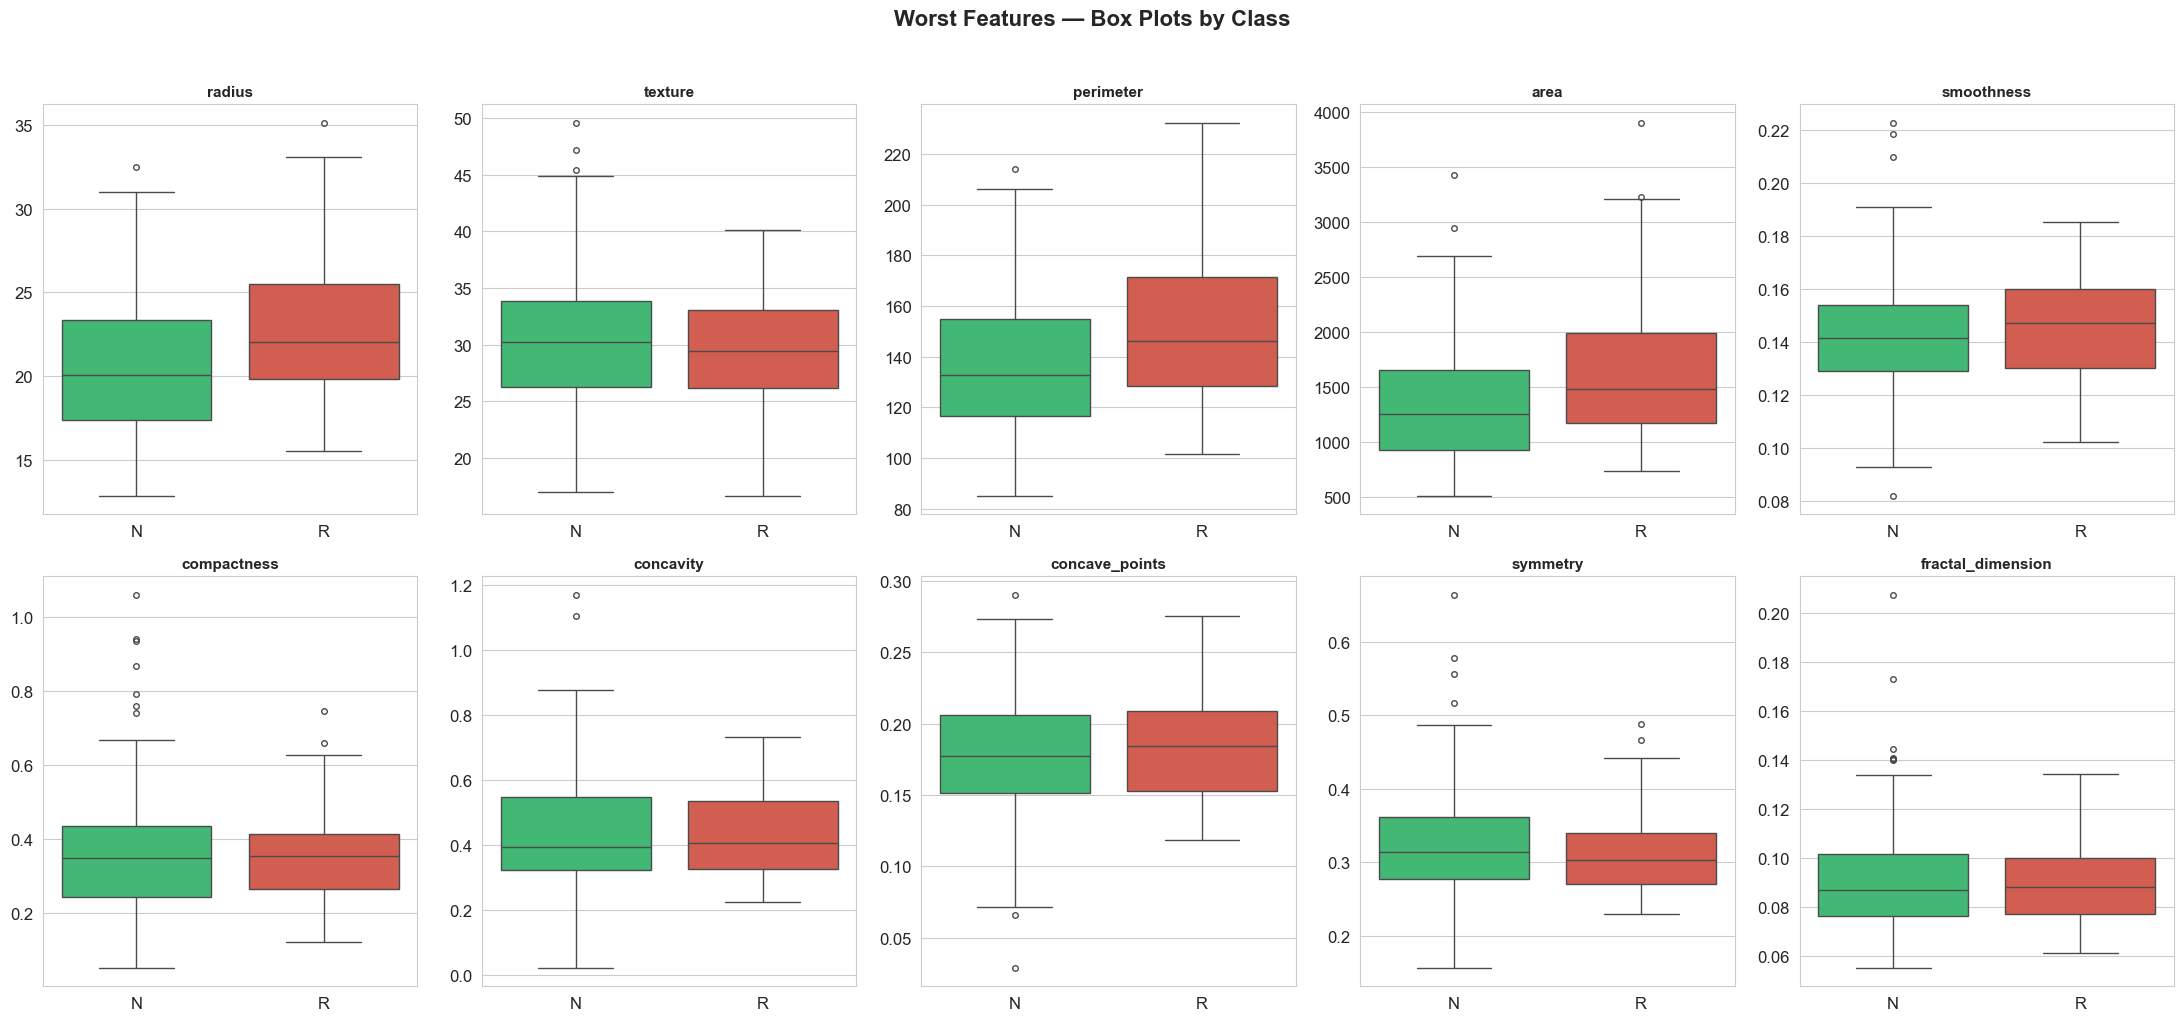

In [13]:
# Box plots for worst features
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.suptitle('Worst Features — Box Plots by Class', fontsize=16, fontweight='bold', y=1.02)

for idx, feature in enumerate(worst_features):
    row, col = idx // 5, idx % 5
    ax = axes[row][col]
    sns.boxplot(x='outcome', y=feature, data=df, ax=ax,
                palette={'N': '#2ecc71', 'R': '#e74c3c'},
                flierprops=dict(marker='o', markersize=4))
    ax.set_title(feature.replace('_worst', ''), fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

**Observations:**
- Outliers are present in **area, perimeter, and radius** features — likely representing unusually large tumors. These are retained as they represent genuine clinical cases.
- The recurrence (R) group shows higher medians for `concavity_worst`, `concave_points_worst`, and `area_worst`.
- **Smoothness and fractal_dimension** show less class separation.

### 3.6 Correlation Analysis

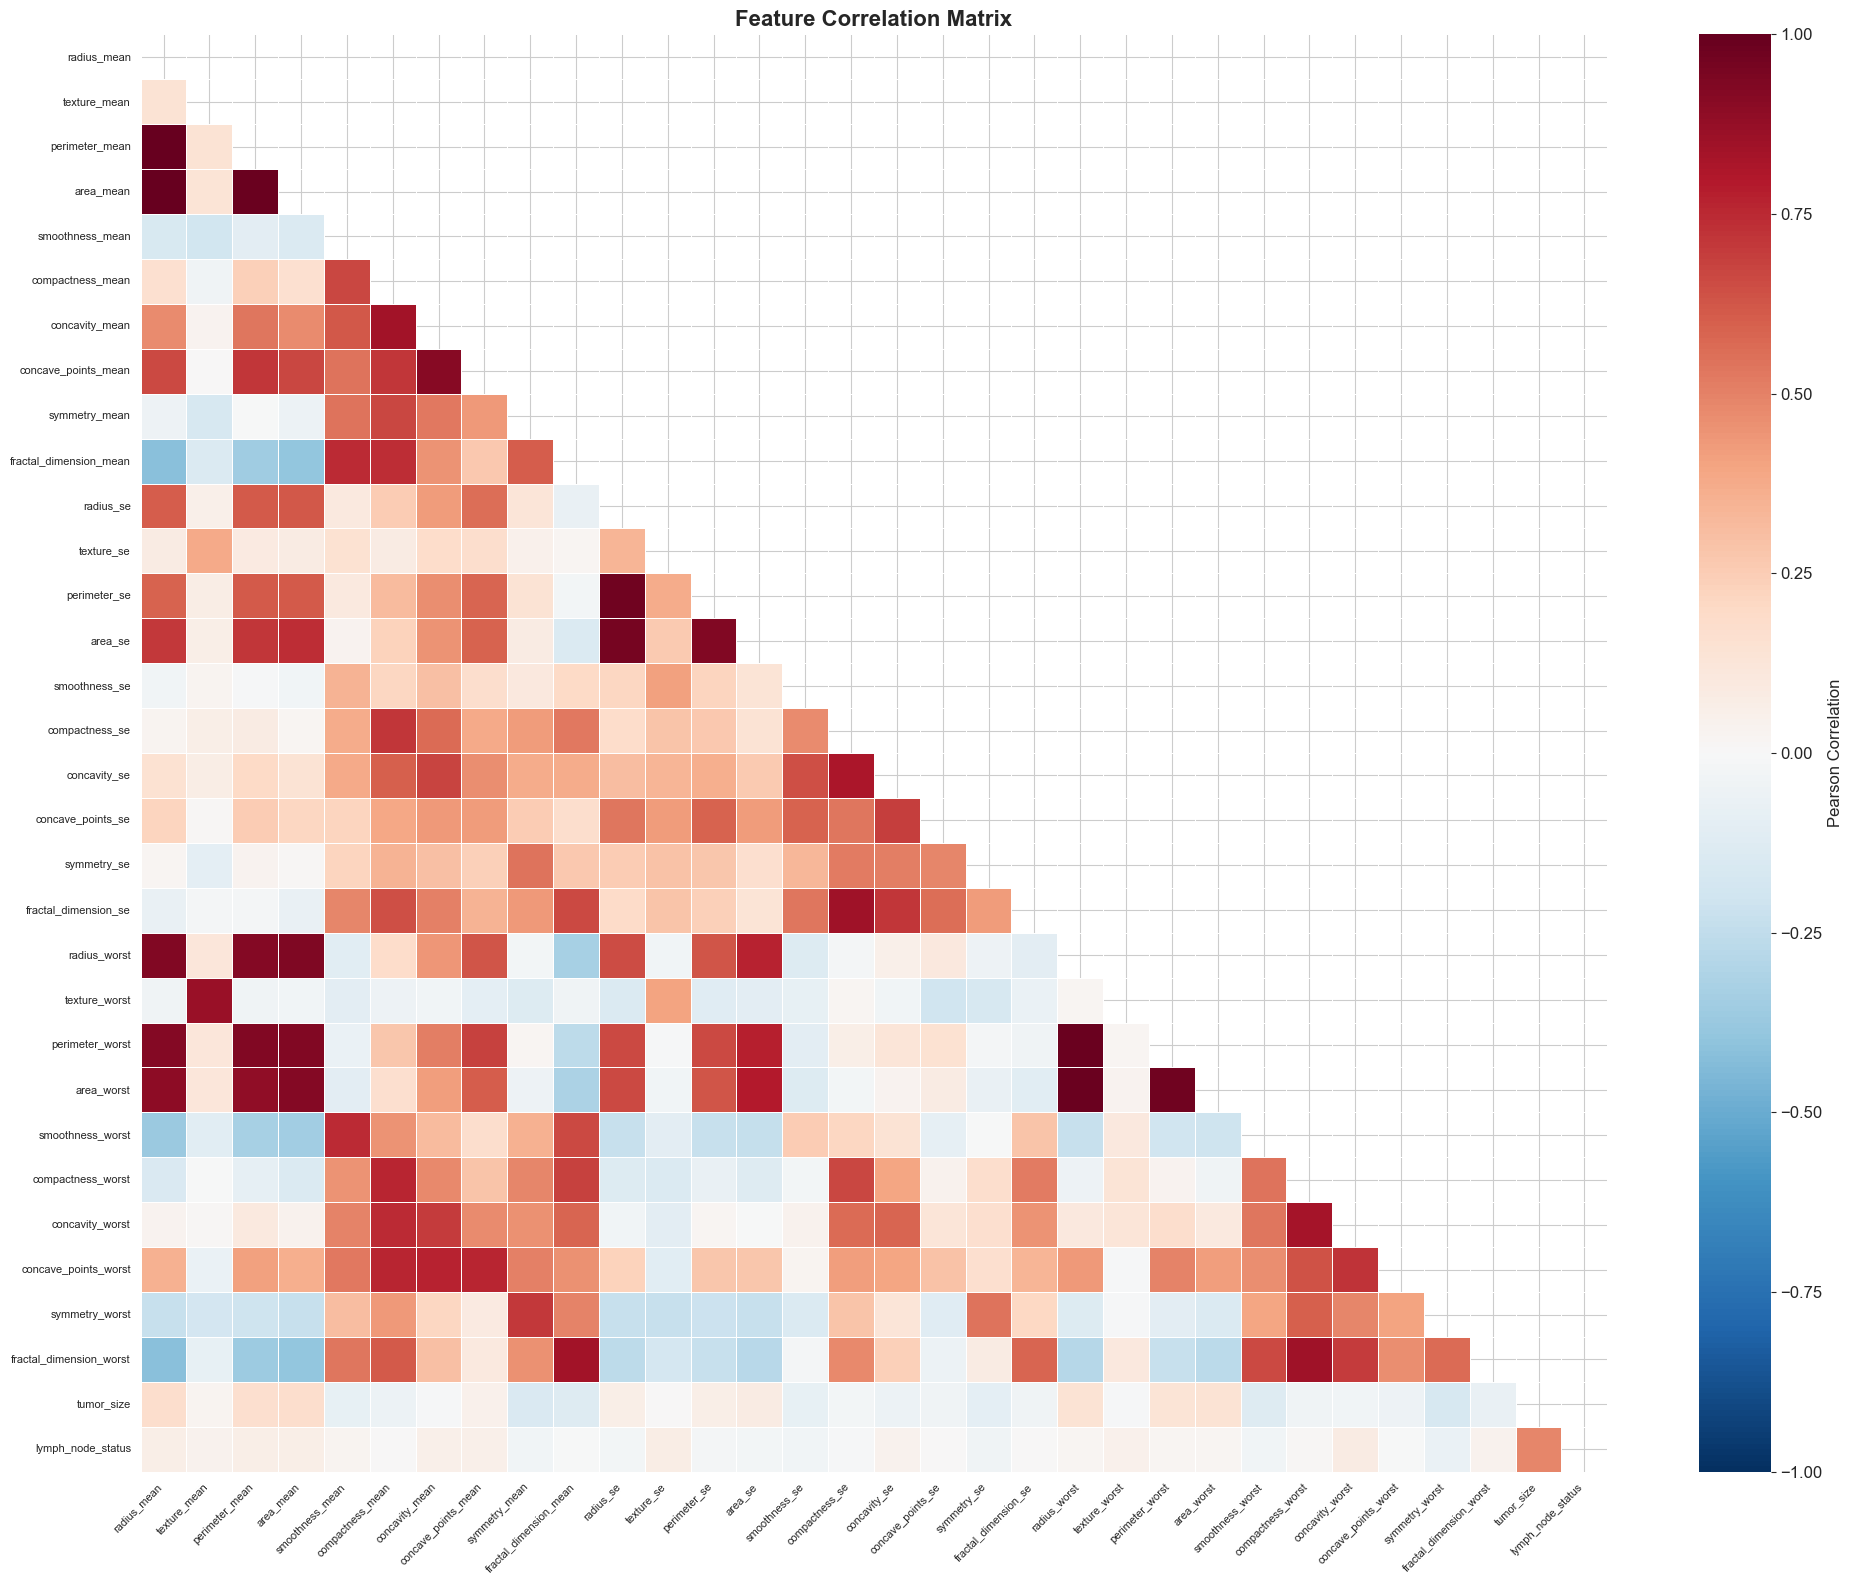

In [14]:
# Correlation matrix (numeric columns, excluding id and time)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id', 'time']]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [15]:
# Find highly correlated feature pairs (|r| > 0.90)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.90:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
print(f"Highly correlated feature pairs (|r| > 0.90): {len(high_corr_df)}")
print("=" * 70)
high_corr_df

Highly correlated feature pairs (|r| > 0.90): 17


,Feature 1,Feature 2,Correlation
0,radius_mean,perimeter_mean,0.996
1,radius_mean,area_mean,0.993
4,perimeter_mean,area_mean,0.991
15,radius_worst,area_worst,0.988
14,radius_worst,perimeter_worst,0.986
16,perimeter_worst,area_worst,0.974
11,radius_se,perimeter_se,0.973
12,radius_se,area_se,0.957
7,area_mean,radius_worst,0.932
13,perimeter_se,area_se,0.930


**Observations:**
- **17 highly correlated feature pairs** (|r| > 0.90) exist, primarily among radius/perimeter/area (geometrically related).
- `radius_mean ↔ perimeter_mean` (r = 0.996) and `radius_mean ↔ area_mean` (r = 0.993) are the strongest pairs.
- High multicollinearity motivates using **ANOVA F-test feature selection** to remove redundant features before modeling.

### 3.7 Feature–Target Correlation

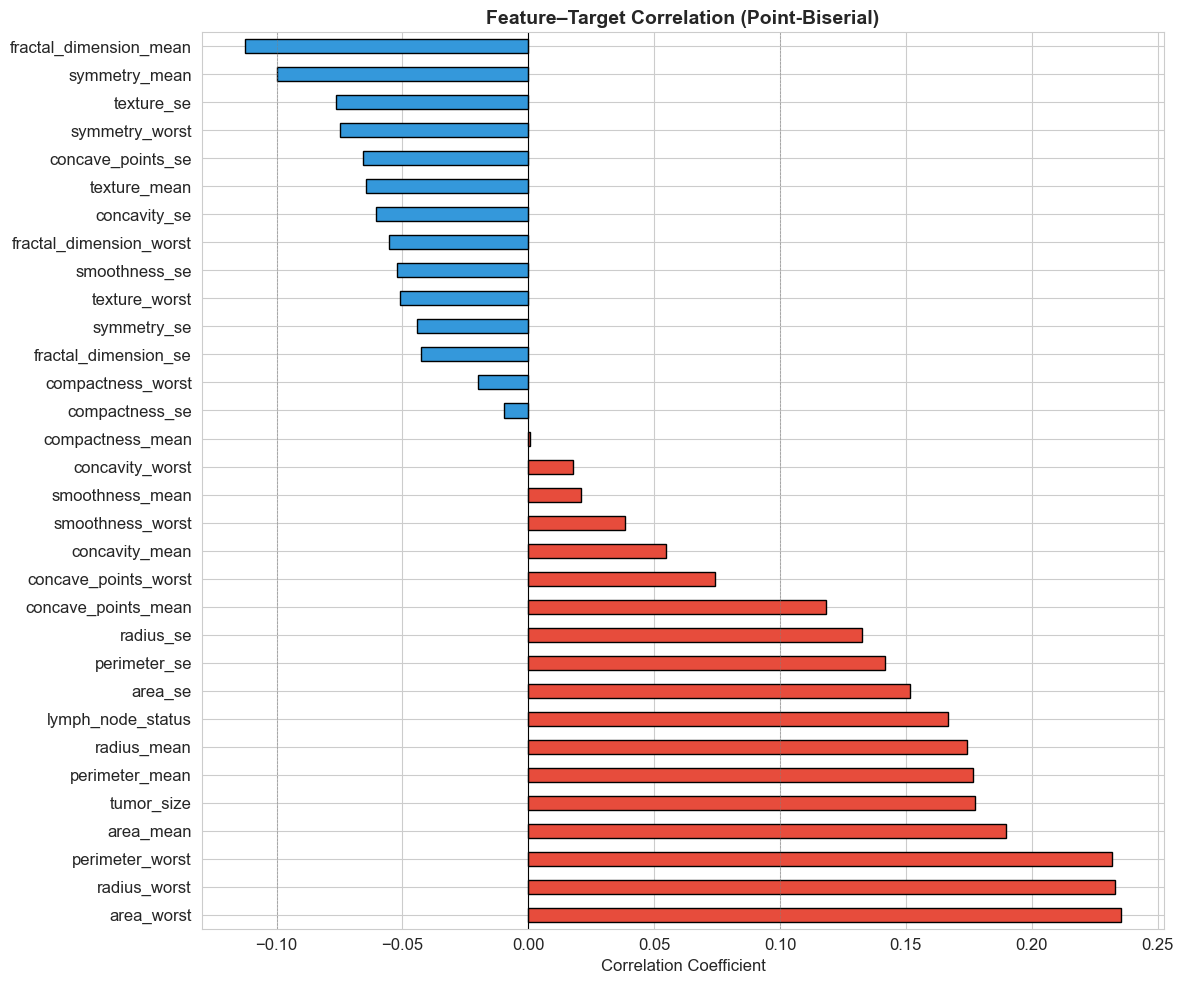


Top 5 positively correlated features (increase recurrence risk):
area_worst         0.235310
radius_worst       0.233225
perimeter_worst    0.231998
area_mean          0.189893
tumor_size         0.177273

Top 5 negatively correlated features:
concave_points_se        -0.065570
symmetry_worst           -0.074731
texture_se               -0.076212
symmetry_mean            -0.099777
fractal_dimension_mean   -0.112352


In [16]:
# Point-biserial correlation between each feature and the binary target
df['outcome_encoded'] = LabelEncoder().fit_transform(df['outcome'])  # N=0, R=1

target_corr = df[numeric_cols + ['outcome_encoded']].corr()['outcome_encoded'].drop('outcome_encoded')
target_corr = target_corr.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
colors_bar = ['#e74c3c' if x > 0 else '#3498db' for x in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black')
ax.set_title('Feature–Target Correlation (Point-Biserial)', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=0.1, color='gray', linewidth=0.5, linestyle='--', alpha=0.7)
ax.axvline(x=-0.1, color='gray', linewidth=0.5, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 5 positively correlated features (increase recurrence risk):")
print(target_corr.head(5).to_string())
print("\nTop 5 negatively correlated features:")
print(target_corr.tail(5).to_string())

**Observations:**
- Strongest positive correlations (recurrence risk): `area_worst` (r=0.235), `radius_worst` (r=0.233), `perimeter_worst` (r=0.232), `area_mean` (r=0.190), `tumor_size` (r=0.177).
- All correlations are low (|r| < 0.24), suggesting **non-linear relationships** — supporting the use of tree-based and kernel methods alongside linear models.

---
## 4. Preprocessing Pipeline

In [17]:
print("PREPROCESSING PIPELINE")
print("=" * 50)

# Step 1: Drop non-informative and leakage columns
# 'id'   — patient identifier, carries no predictive signal
# 'time' — follow-up duration; its class-conditional distribution leaks the target
# 'outcome_encoded' — temporary column created for EDA
# 'outcome' — target variable, separated below
columns_to_drop = ['id', 'time', 'outcome_encoded', 'outcome']
X = df.drop(columns=columns_to_drop)
y = LabelEncoder().fit_transform(df['outcome'])  # N=0, R=1

print(f"Step 1 — Dropped: {['id', 'time']}")
print(f"         Feature matrix: {X.shape}")
print(f"\nStep 2 — Target encoded: N→0, R→1")
print(f"         Class counts: 0 (N) = {sum(y==0)}, 1 (R) = {sum(y==1)}")

PREPROCESSING PIPELINE
Step 1 — Dropped: ['id', 'time']
         Feature matrix: (198, 32)

Step 2 — Target encoded: N→0, R→1
         Class counts: 0 (N) = 151, 1 (R) = 47


In [18]:
# Data leakage validation for 'time' column
print("=" * 60)
print("DATA LEAKAGE VALIDATION REPORT")
print("=" * 60)

print(f"\n'time' in feature matrix: {'time' in X.columns}")
print(f"'id'   in feature matrix: {'id' in X.columns}")

time_corr = df['time'].corr(df['outcome_encoded'] if 'outcome_encoded' in df.columns 
                            else LabelEncoder().fit_transform(df['outcome']))

# Recompute for display
le_temp = LabelEncoder().fit_transform(df['outcome'])
time_corr_val = df['time'].corr(pd.Series(le_temp, index=df.index))
print(f"\n'time' ↔ outcome correlation: {time_corr_val:.4f}")

# Class-conditional follow-up duration
time_stats = df.groupby('outcome')['time'].agg(['mean', 'std'])
print(f"\nMean follow-up duration:")
print(time_stats.to_string())
print("\nConclusion: Recurrence (R) and Non-Recurrence (N) groups have different"
      "\nfollow-up durations by definition — including 'time' would directly leak the label.")

DATA LEAKAGE VALIDATION REPORT

'time' in feature matrix: False
'id'   in feature matrix: False

'time' ↔ outcome correlation: -0.3513

Mean follow-up duration:
              mean        std
outcome                      
N        53.470199  34.771024
R        25.085106  22.718341

Conclusion: Recurrence (R) and Non-Recurrence (N) groups have different
follow-up durations by definition — including 'time' would directly leak the label.


In [19]:
# Step 3: Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Step 3 — Stratified Split (80/20)")
print(f"         Train: {X_train.shape[0]} samples (N={sum(y_train==0)}, R={sum(y_train==1)})")
print(f"         Test : {X_test.shape[0]} samples (N={sum(y_test==0)}, R={sum(y_test==1)})")

# Step 4: StandardScaler — fit on train, transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # transform only — no fit on test set

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns, index=X_test.index)

print(f"\nStep 4 — StandardScaler applied (fit on train only).")

Step 3 — Stratified Split (80/20)
         Train: 158 samples (N=120, R=38)
         Test : 40 samples (N=31, R=9)

Step 4 — StandardScaler applied (fit on train only).


In [20]:
# Step 5: SMOTE — applied to training set only
# Synthetic samples are generated for the minority class (R) to achieve 1:1 balance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Step 5 — SMOTE (Synthetic Minority Over-sampling)")
print(f"         Before: N={sum(y_train==0)}, R={sum(y_train==1)} (total {len(y_train)})")
print(f"         After : N={sum(y_train_resampled==0)}, R={sum(y_train_resampled==1)} (total {len(y_train_resampled)})")
print(f"\n         Note: SMOTE was applied ONLY to the training set.")
print(f"         Test set remains at original distribution (N={sum(y_test==0)}, R={sum(y_test==1)}).")

Step 5 — SMOTE (Synthetic Minority Over-sampling)
         Before: N=120, R=38 (total 158)
         After : N=120, R=120 (total 240)

         Note: SMOTE was applied ONLY to the training set.
         Test set remains at original distribution (N=31, R=9).


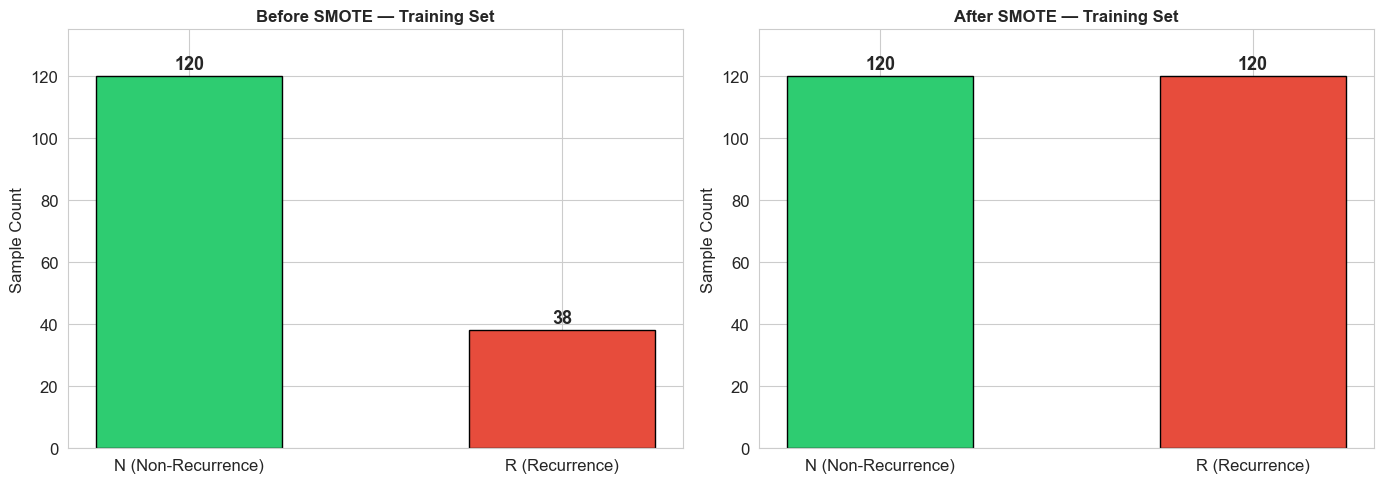

In [21]:
# SMOTE validation visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels_smote = ['N (Non-Recurrence)', 'R (Recurrence)']
counts_before = [sum(y_train==0), sum(y_train==1)]
counts_after  = [sum(y_train_resampled==0), sum(y_train_resampled==1)]

for ax, counts, title in zip(axes,
                              [counts_before, counts_after],
                              ['Before SMOTE — Training Set', 'After SMOTE — Training Set']):
    bars = ax.bar(labels_smote, counts, color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Sample Count')
    ax.set_ylim([0, max(max(counts_before), max(counts_after)) + 15])
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

**Preprocessing summary:**
1. `id` and `time` removed — `time` carries data leakage (correlation −0.35 with outcome; class-conditional means: N=53.5 mo vs R=25.1 mo)
2. Target encoded: N→0, R→1
3. Stratified 80/20 split: Train=158 (N=120, R=38), Test=40 (N=31, R=9)
4. StandardScaler fitted on training set only
5. SMOTE applied to training set: 158 → 240 samples (1:1 class balance); test set untouched

---
## 5. Feature Selection (ANOVA F-test)

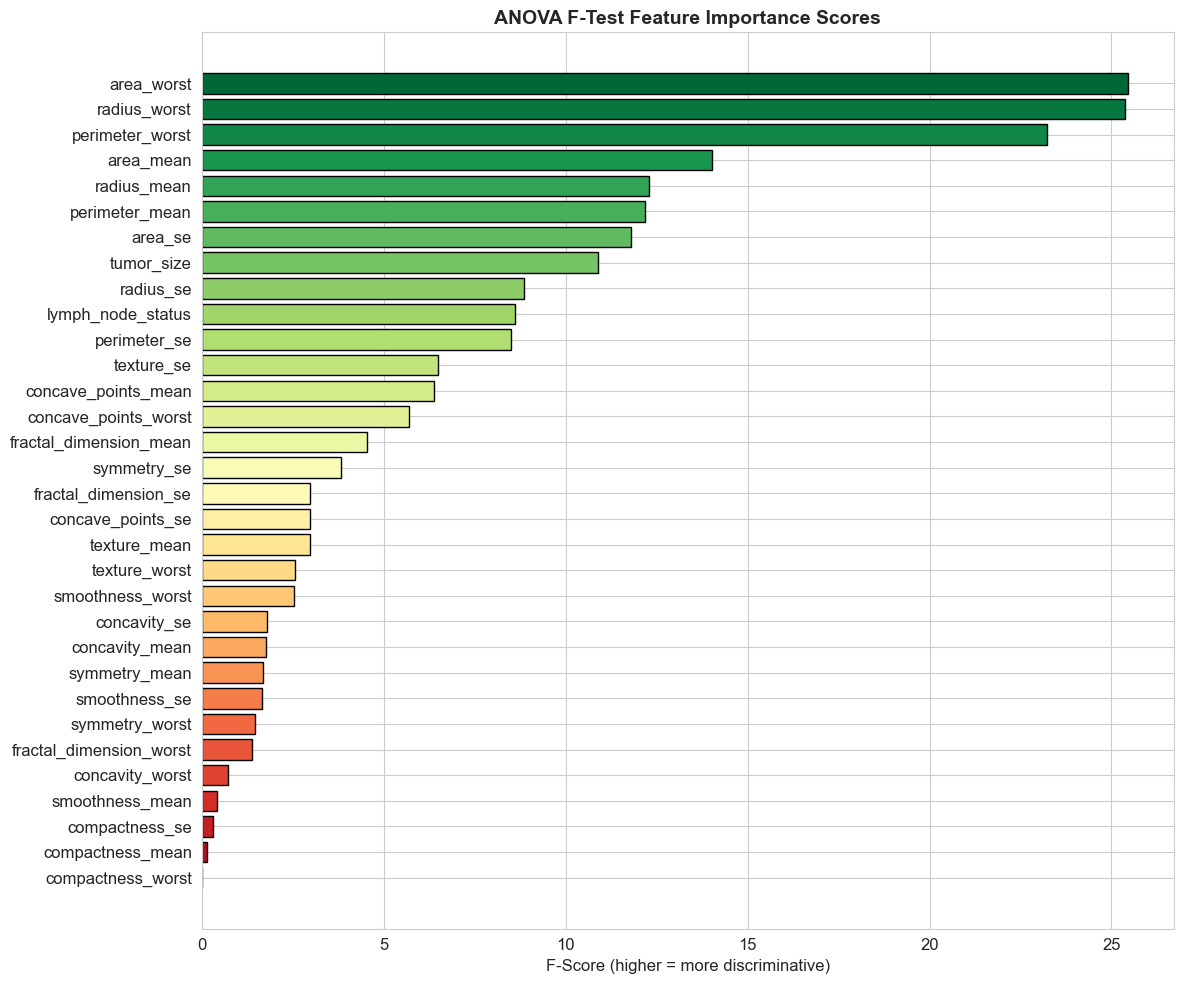

Statistically significant features (p < 0.05): 15 / 32

Top 15 features by F-score:
               Feature   F-Score      p-value
            area_worst 25.445652 9.028610e-07
          radius_worst 25.359247 9.401400e-07
       perimeter_worst 23.236752 2.554532e-06
             area_mean 14.013953 2.275827e-04
           radius_mean 12.290830 5.438570e-04
        perimeter_mean 12.174531 5.770596e-04
               area_se 11.789837 7.023315e-04
            tumor_size 10.881790 1.119856e-03
             radius_se  8.861810 3.212610e-03
     lymph_node_status  8.607127 3.675707e-03
          perimeter_se  8.493886 3.903072e-03
            texture_se  6.482562 1.152538e-02
   concave_points_mean  6.394108 1.209758e-02
  concave_points_worst  5.705249 1.769464e-02
fractal_dimension_mean  4.549750 3.394712e-02


In [22]:
# ANOVA F-test — score all 32 features
selector = SelectKBest(f_classif, k='all')
selector.fit(X_train_resampled, y_train_resampled)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-Score', ascending=False)

# Visualization
fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(feature_scores['Feature'], feature_scores['F-Score'],
               color=plt.cm.RdYlGn_r(np.linspace(0, 1, len(feature_scores))),
               edgecolor='black')
ax.set_title('ANOVA F-Test Feature Importance Scores', fontsize=14, fontweight='bold')
ax.set_xlabel('F-Score (higher = more discriminative)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

significant_features = feature_scores[feature_scores['p-value'] < 0.05]
print(f"Statistically significant features (p < 0.05): {len(significant_features)} / {len(feature_scores)}")
print(f"\nTop 15 features by F-score:")
print(feature_scores.head(15).to_string(index=False))

In [23]:
# Select top 15 features
k_best = 15
top_features = feature_scores.head(k_best)['Feature'].tolist()

X_train_selected = X_train_resampled[top_features]
X_test_selected  = X_test_scaled[top_features]

print(f"Selected {k_best} features (dimensionality: 32 → {k_best}):")
for i, feat in enumerate(top_features, 1):
    score = feature_scores[feature_scores['Feature'] == feat]['F-Score'].values[0]
    print(f"  {i:2d}. {feat:<30s} (F={score:.2f})")

print(f"\nTrain set shape (selected): {X_train_selected.shape}")
print(f"Test  set shape (selected): {X_test_selected.shape}")

Selected 15 features (dimensionality: 32 → 15):
   1. area_worst                     (F=25.45)
   2. radius_worst                   (F=25.36)
   3. perimeter_worst                (F=23.24)
   4. area_mean                      (F=14.01)
   5. radius_mean                    (F=12.29)
   6. perimeter_mean                 (F=12.17)
   7. area_se                        (F=11.79)
   8. tumor_size                     (F=10.88)
   9. radius_se                      (F=8.86)
  10. lymph_node_status              (F=8.61)
  11. perimeter_se                   (F=8.49)
  12. texture_se                     (F=6.48)
  13. concave_points_mean            (F=6.39)
  14. concave_points_worst           (F=5.71)
  15. fractal_dimension_mean         (F=4.55)

Train set shape (selected): (240, 15)
Test  set shape (selected): (40, 15)


**Feature selection summary:**
- 15 features are statistically significant (p < 0.05); dimensionality reduced from 32 → 15
- Top features by F-score: `area_worst` (F=25.45), `radius_worst` (F=25.36), `perimeter_worst` (F=23.24)
- Clinical features `tumor_size` (F=10.88) and `lymph_node_status` (F=8.61) also contribute significantly
- Dimension reduction reduces overfitting risk and removes multicollinear features

---
## 6. Model Training & Baseline Evaluation

Six classifiers are trained with default parameters. All use the SMOTE-balanced, scaled, 15-feature training set. Performance is estimated via 5-fold stratified cross-validation (F1 scoring) and validated on the held-out test set.

In [24]:
# Define classifiers
models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors':  KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':        DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=5, learning_rate=0.1),
    'SVM':                  SVC(kernel='rbf', probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("BASELINE MODEL EVALUATION")
print("=" * 90)
print(f"{'Model':<25s} {'CV F1':>14s} {'Accuracy':>10s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s}")
print("-" * 90)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_selected, y_train_resampled, cv=cv, scoring='f1')
    model.fit(X_train_selected, y_train_resampled)
    y_pred = model.predict(X_test_selected)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'CV F1 (mean ± std)': f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f}",
        'Test Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1
    })
    print(f"{name:<25s} {cv_scores.mean():>8.3f} ± {cv_scores.std():.3f} {acc:>10.3f} {prec:>10.3f} {rec:>10.3f} {f1:>10.3f}")

print("=" * 90)
results_df = pd.DataFrame(results)
results_df

BASELINE MODEL EVALUATION
Model                              CV F1   Accuracy  Precision     Recall         F1
------------------------------------------------------------------------------------------
Logistic Regression          0.606 ± 0.104      0.675      0.333      0.444      0.381
K-Nearest Neighbors          0.716 ± 0.058      0.600      0.333      0.778      0.467
Decision Tree                0.730 ± 0.033      0.575      0.250      0.444      0.320
Random Forest                0.853 ± 0.026      0.625      0.125      0.111      0.118
Gradient Boosting            0.799 ± 0.033      0.675      0.250      0.222      0.235
SVM                          0.696 ± 0.035      0.750      0.429      0.333      0.375


,Model,CV F1 (mean ± std),Test Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.606 ± 0.104,0.675,0.333333,0.444444,0.380952
1,K-Nearest Neighbors,0.716 ± 0.058,0.600,0.333333,0.777778,0.466667
2,Decision Tree,0.730 ± 0.033,0.575,0.250000,0.444444,0.320000
3,Random Forest,0.853 ± 0.026,0.625,0.125000,0.111111,0.117647
4,Gradient Boosting,0.799 ± 0.033,0.675,0.250000,0.222222,0.235294
5,SVM,0.696 ± 0.035,0.750,0.428571,0.333333,0.375000


---
## 7. Confusion Matrices

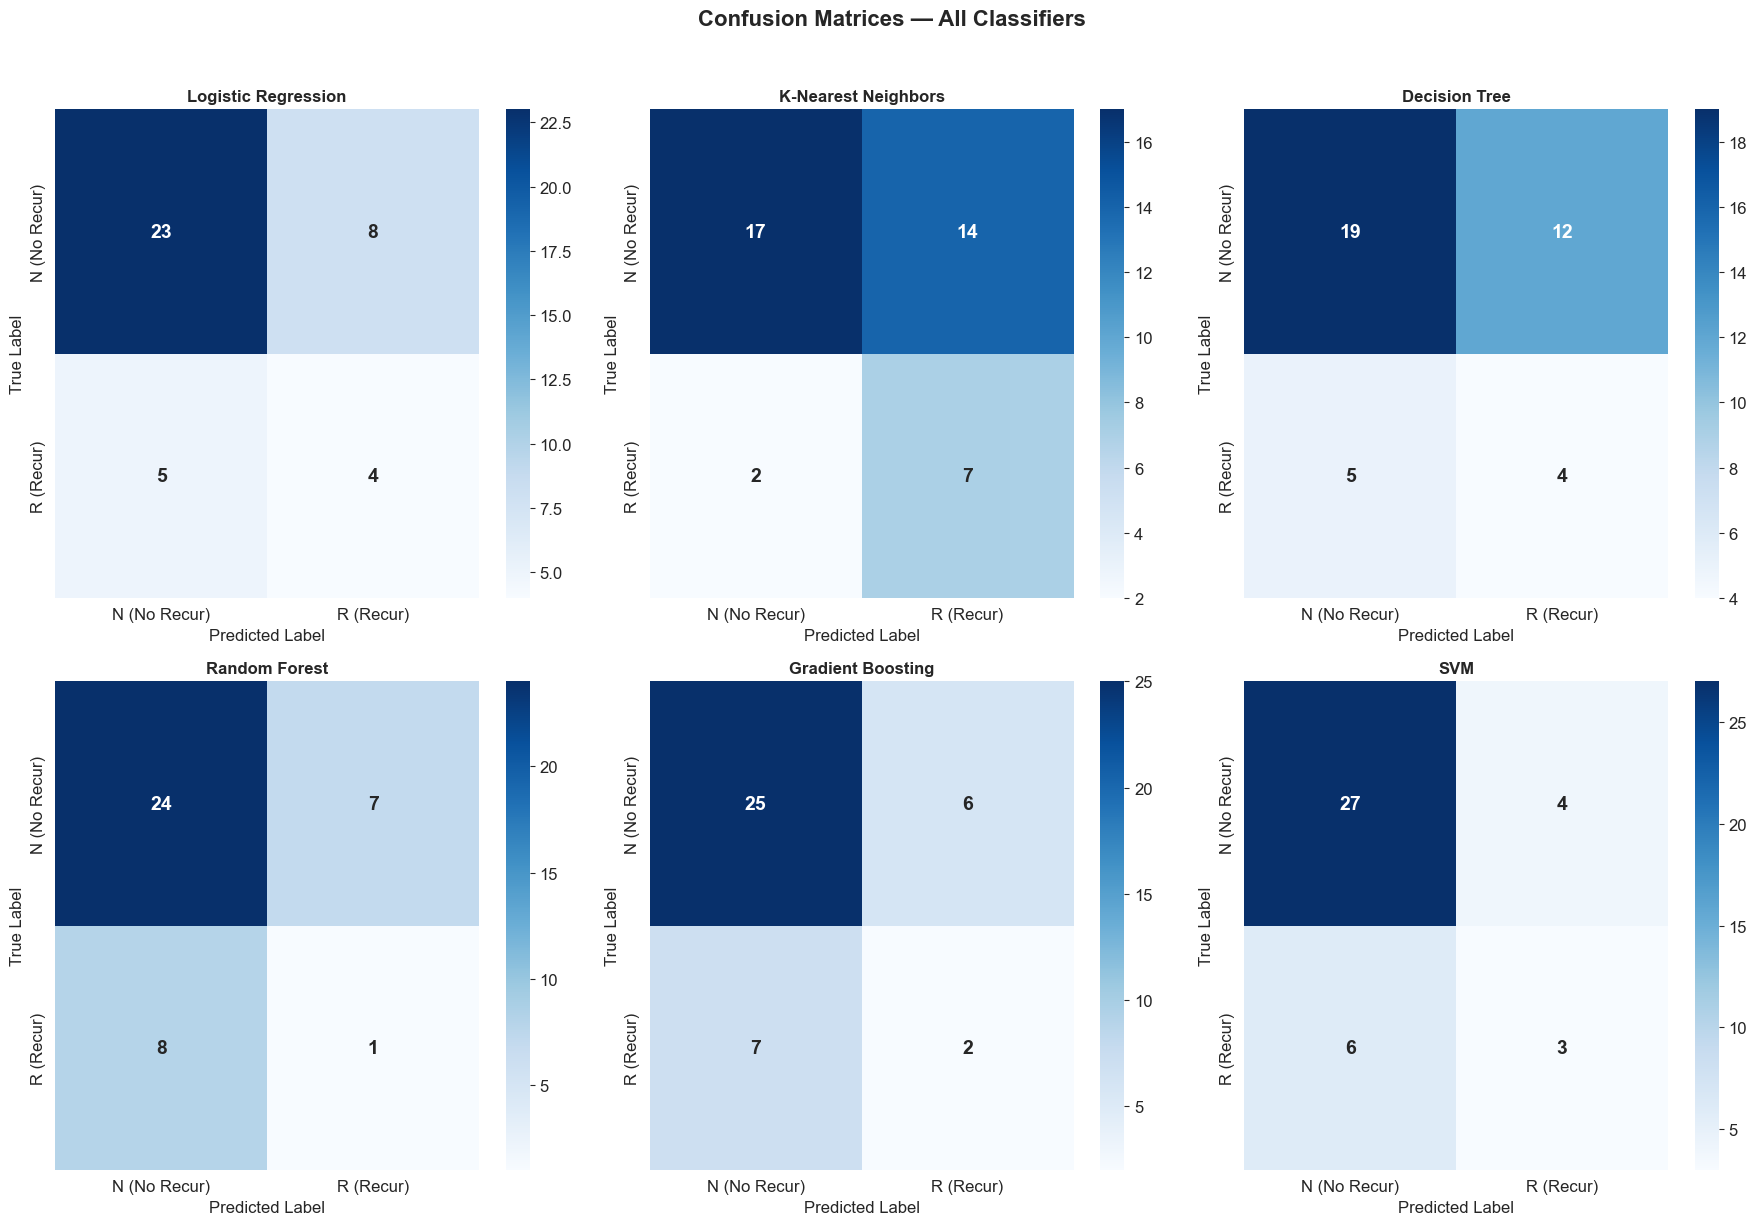

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confusion Matrices — All Classifiers', fontsize=16, fontweight='bold', y=1.02)

for idx, (name, model) in enumerate(models.items()):
    row, col = idx // 3, idx % 3
    ax = axes[row][col]

    y_pred = model.predict(X_test_selected)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['N (No Recur)', 'R (Recur)'],
                yticklabels=['N (No Recur)', 'R (Recur)'],
                annot_kws={'size': 14, 'fontweight': 'bold'})
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

**Clinical interpretation:** In a medical screening context, **False Negatives (FN)** — recurrence cases classified as non-recurrence — are the most dangerous error type. Models with higher Recall for class R are preferred, even at the cost of lower Precision.

---
## 8. ROC Curves & AUC

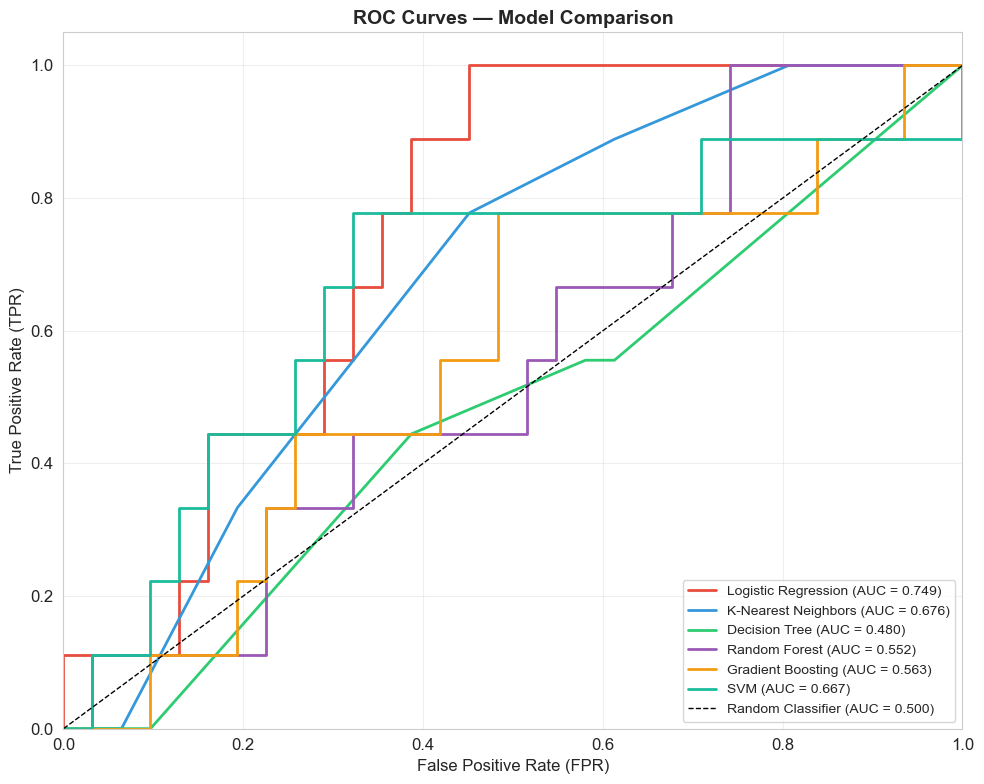

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))

colors_roc = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

for idx, (name, model) in enumerate(models.items()):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_selected)[:, 1]
    else:
        y_prob = model.decision_function(X_test_selected)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors_roc[idx], linewidth=2,
            label=f'{name} (AUC = {auc_val:.3f})')

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')

ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**AUC Results:**

| Model | AUC |
|---|---|
| **Logistic Regression** | **0.749** |
| K-Nearest Neighbors | 0.676 |
| SVM | 0.667 |
| Gradient Boosting | 0.563 |
| Random Forest | 0.552 |
| Decision Tree | 0.480 |

Logistic Regression achieves the best threshold-independent discrimination. AUC values generally in the 0.5–0.75 range reflect the inherent difficulty of this small-N classification problem.

---
## 9. Model Performance Comparison

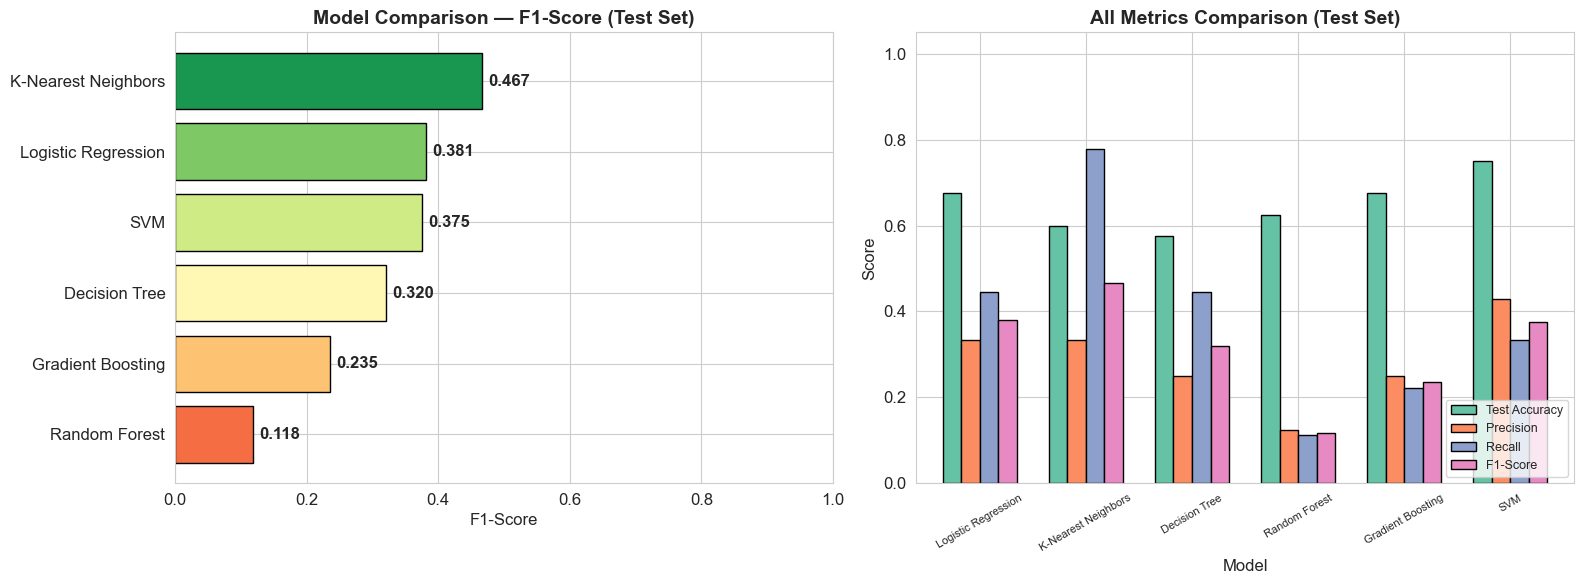

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1-Score comparison
f1_sorted = results_df.sort_values('F1-Score', ascending=True)
bars = axes[0].barh(f1_sorted['Model'], f1_sorted['F1-Score'],
                    color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(f1_sorted))),
                    edgecolor='black')
axes[0].set_title('Model Comparison — F1-Score (Test Set)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('F1-Score')
axes[0].set_xlim([0, 1])
for bar, val in zip(bars, f1_sorted['F1-Score']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2.,
                f'{val:.3f}', va='center', fontweight='bold')

# All metrics comparison
metrics_compare = results_df[['Model', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score']].set_index('Model')
metrics_compare.plot(kind='bar', ax=axes[1], rot=30, edgecolor='black', width=0.7)
axes[1].set_title('All Metrics Comparison (Test Set)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0, 1.05])
axes[1].legend(loc='lower right', fontsize=9)
axes[1].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

In [28]:
# Detailed classification report for the best model by F1
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_selected)

print(f"BEST MODEL (by F1-Score): {best_model_name}")
print("=" * 60)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_best,
                            target_names=['N (Non-Recurrence)', 'R (Recurrence)']))

BEST MODEL (by F1-Score): K-Nearest Neighbors

Detailed Classification Report:
                    precision    recall  f1-score   support

N (Non-Recurrence)       0.89      0.55      0.68        31
    R (Recurrence)       0.33      0.78      0.47         9

          accuracy                           0.60        40
         macro avg       0.61      0.66      0.57        40
      weighted avg       0.77      0.60      0.63        40



---
## 10. Overfitting Analysis

In [29]:
print("=" * 70)
print("OVERFITTING ANALYSIS: TRAIN vs TEST F1")
print("=" * 70)

train_f1_scores = {}
test_f1_scores  = {}
overfitting_gaps = {}

for name, model in models.items():
    train_f1 = f1_score(y_train_resampled, model.predict(X_train_selected))
    test_f1  = f1_score(y_test, model.predict(X_test_selected))
    train_f1_scores[name] = train_f1
    test_f1_scores[name]  = test_f1
    overfitting_gaps[name] = train_f1 - test_f1

print(f"\n{'Model':<25} {'Train F1':>10} {'Test F1':>10} {'Gap':>10} {'Status':>20}")
print("-" * 78)

for name in models.keys():
    gap = overfitting_gaps[name]
    status = "SEVERE" if gap > 0.3 else "MODERATE" if gap > 0.15 else "MILD" if gap > 0.05 else "GOOD"
    print(f"{name:<25} {train_f1_scores[name]:>10.3f} {test_f1_scores[name]:>10.3f} {gap:>10.3f} {status:>20}")

OVERFITTING ANALYSIS: TRAIN vs TEST F1

Model                       Train F1    Test F1        Gap               Status
------------------------------------------------------------------------------
Logistic Regression            0.639      0.381      0.258             MODERATE
K-Nearest Neighbors            0.816      0.467      0.350               SEVERE
Decision Tree                  0.890      0.320      0.570               SEVERE
Random Forest                  1.000      0.118      0.882               SEVERE
Gradient Boosting              1.000      0.235      0.765               SEVERE
SVM                            0.740      0.375      0.365               SEVERE


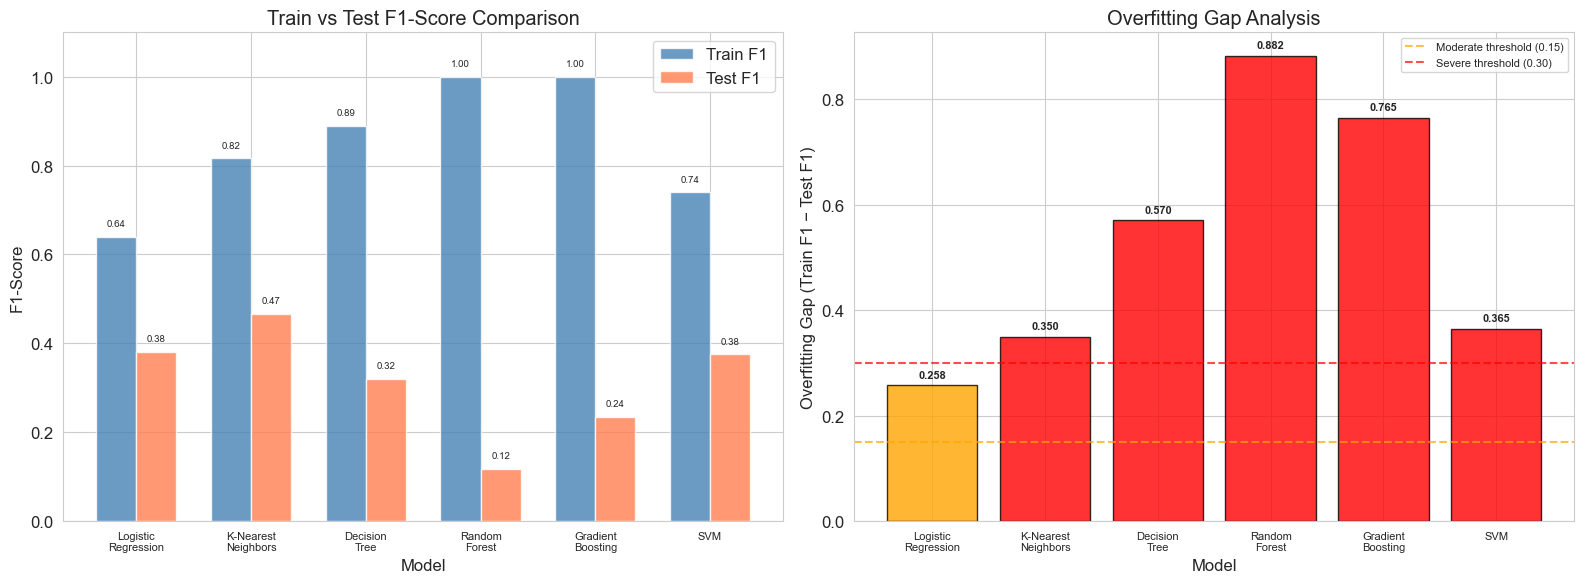

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names_short = [name.replace(' ', '\n') for name in models.keys()]
x = np.arange(len(models))
width = 0.35

# Left: Train vs Test F1
bars1 = axes[0].bar(x - width/2, list(train_f1_scores.values()), width,
                    label='Train F1', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, list(test_f1_scores.values()), width,
                    label='Test F1',  color='coral',     alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('Train vs Test F1-Score Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names_short, fontsize=8)
axes[0].legend()
axes[0].set_ylim(0, 1.1)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

# Right: Overfitting gap
gap_colors = ['red' if g > 0.3 else 'orange' if g > 0.15 else 'lightgreen' if g > 0.05 else 'green'
              for g in overfitting_gaps.values()]
bars3 = axes[1].bar(x, list(overfitting_gaps.values()), color=gap_colors, alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Overfitting Gap (Train F1 − Test F1)')
axes[1].set_title('Overfitting Gap Analysis')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names_short, fontsize=8)
axes[1].axhline(y=0.15, color='orange', linestyle='--', alpha=0.7, label='Moderate threshold (0.15)')
axes[1].axhline(y=0.30, color='red',    linestyle='--', alpha=0.7, label='Severe threshold (0.30)')
axes[1].legend(fontsize=8)
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

**Overfitting analysis results:**

| Model | Train F1 | Test F1 | Gap | Status |
|---|---|---|---|---|
| Logistic Regression | 0.639 | 0.381 | 0.258 | Moderate |
| K-Nearest Neighbors | 0.816 | 0.467 | 0.350 | Severe |
| Decision Tree | 0.890 | 0.320 | 0.570 | Severe |
| **Random Forest** | **1.000** | **0.118** | **0.882** | **Severe** |
| **Gradient Boosting** | **1.000** | **0.235** | **0.765** | **Severe** |
| SVM | 0.740 | 0.375 | 0.365 | Severe |

- **Random Forest and Gradient Boosting** memorize training data (F1=1.0) but collapse on the test set — classic high-variance overfitting.
- **Logistic Regression** has the smallest gap (0.258) and is the most stable generalizer on this small dataset.
- Root causes: only 198 samples; SMOTE synthetic examples inflate training performance; tree ensembles are structurally high-variance.

---
## 11. Hyperparameter Optimization (GridSearchCV)

Systematic grid search over hyperparameter spaces for all six classifiers. Optimization objective: **F1-score** via 5-fold stratified cross-validation.

In [31]:
# Hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'max_iter': [5000]
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'Decision Tree': {
        'max_depth': [2, 3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10],
        'criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 5],
        'max_features': ['sqrt', 'log2']
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [2, 3, 5],
        'min_samples_split': [2, 5, 10],
        'subsample': [0.8, 1.0]
    },
    'SVM': {
        'C': [0.01, 0.1, 1, 10, 100],
        'kernel': ['rbf', 'linear', 'poly'],
        'gamma': ['scale', 'auto', 0.01, 0.1]
    }
}

# Base estimators for grid search
base_estimators = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'SVM':                 SVC(random_state=42, probability=True)
}

print("=" * 70)
print("GRIDSEARCHCV HYPERPARAMETER OPTIMIZATION")
print("=" * 70)

best_models = {}
grid_results = {}
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name in base_estimators:
    print(f"\nSearching: {name}...")
    gs = GridSearchCV(
        estimator=base_estimators[name],
        param_grid=param_grids[name],
        cv=cv_inner, scoring='f1',
        n_jobs=-1, verbose=0, refit=True
    )
    gs.fit(X_train_selected, y_train_resampled)

    best_models[name] = gs.best_estimator_
    grid_results[name] = {
        'best_params': gs.best_params_,
        'best_cv_f1': gs.best_score_,
        'n_combinations': len(gs.cv_results_['mean_test_score'])
    }
    print(f"  Best CV F1: {gs.best_score_:.4f}")
    print(f"  Best params: {gs.best_params_}")
    print(f"  Combinations tried: {grid_results[name]['n_combinations']}")

print("\n" + "=" * 70)
print("GridSearchCV complete.")
print("=" * 70)

GRIDSEARCHCV HYPERPARAMETER OPTIMIZATION

Searching: Logistic Regression...
  Best CV F1: 0.6667
  Best params: {'C': 0.001, 'max_iter': 5000, 'penalty': 'l1', 'solver': 'saga'}
  Combinations tried: 24

Searching: K-Nearest Neighbors...
  Best CV F1: 0.7633
  Best params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  Combinations tried: 42

Searching: Decision Tree...
  Best CV F1: 0.7351
  Best params: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}
  Combinations tried: 192

Searching: Random Forest...
  Best CV F1: 0.8531
  Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Combinations tried: 270

Searching: Gradient Boosting...
  Best CV F1: 0.8241
  Best params: {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}
  Combinations tried: 216

Searching: SVM...
  Best CV F1: 0.8438
  Best params: {'C'

In [32]:
# Compare baseline vs optimized performance (test set)
print("=" * 90)
print("BEFORE vs AFTER OPTIMIZATION (Test Set)")
print("=" * 90)

before_f1 = {}
after_f1  = {}
after_metrics = {}

for name in best_models:
    y_pred_before = models[name].predict(X_test_selected)
    before_f1[name] = f1_score(y_test, y_pred_before)

    y_pred_after = best_models[name].predict(X_test_selected)
    after_f1[name] = f1_score(y_test, y_pred_after)
    after_metrics[name] = {
        'accuracy':  accuracy_score(y_test, y_pred_after),
        'precision': precision_score(y_test, y_pred_after, zero_division=0),
        'recall':    recall_score(y_test, y_pred_after),
        'f1':        f1_score(y_test, y_pred_after)
    }

print(f"\n{'Model':<25} {'Before F1':>12} {'After F1':>12} {'Change':>12} {'Status':>12}")
print("-" * 75)

for name in best_models:
    delta = after_f1[name] - before_f1[name]
    status = "Improved" if delta > 0.05 else "Similar" if delta > -0.05 else "Declined"
    print(f"{name:<25} {before_f1[name]:>12.4f} {after_f1[name]:>12.4f} {delta:>+12.4f} {status:>12}")

print(f"\n\n{'='*90}")
print("OPTIMIZED MODEL DETAILED RESULTS (Test Set)")
print(f"{'='*90}")
print(f"\n{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 65)
for name in best_models:
    m = after_metrics[name]
    print(f"{name:<25} {m['accuracy']:>10.4f} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>10.4f}")

best_opt_name = max(after_f1, key=after_f1.get)
print(f"\nBest optimized model: {best_opt_name} (F1 = {after_f1[best_opt_name]:.4f})")
print(f"Best parameters: {grid_results[best_opt_name]['best_params']}")

y_pred_opt = best_models[best_opt_name].predict(X_test_selected)
print(f"\nClassification report:")
print(classification_report(y_test, y_pred_opt, target_names=['Non-Recurrence (N)', 'Recurrence (R)']))

BEFORE vs AFTER OPTIMIZATION (Test Set)

Model                        Before F1     After F1       Change       Status
---------------------------------------------------------------------------
Logistic Regression             0.3810       0.3673      -0.0136      Similar
K-Nearest Neighbors             0.4667       0.4000      -0.0667     Declined
Decision Tree                   0.3200       0.2609      -0.0591     Declined
Random Forest                   0.1176       0.1250      +0.0074      Similar
Gradient Boosting               0.2353       0.2353      +0.0000      Similar
SVM                             0.3750       0.2353      -0.1397     Declined


OPTIMIZED MODEL DETAILED RESULTS (Test Set)

Model                       Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Logistic Regression           0.2250     0.2250     1.0000     0.3673
K-Nearest Neighbors           0.6250     0.3125     0.5556     0.4000
Decision Tree 

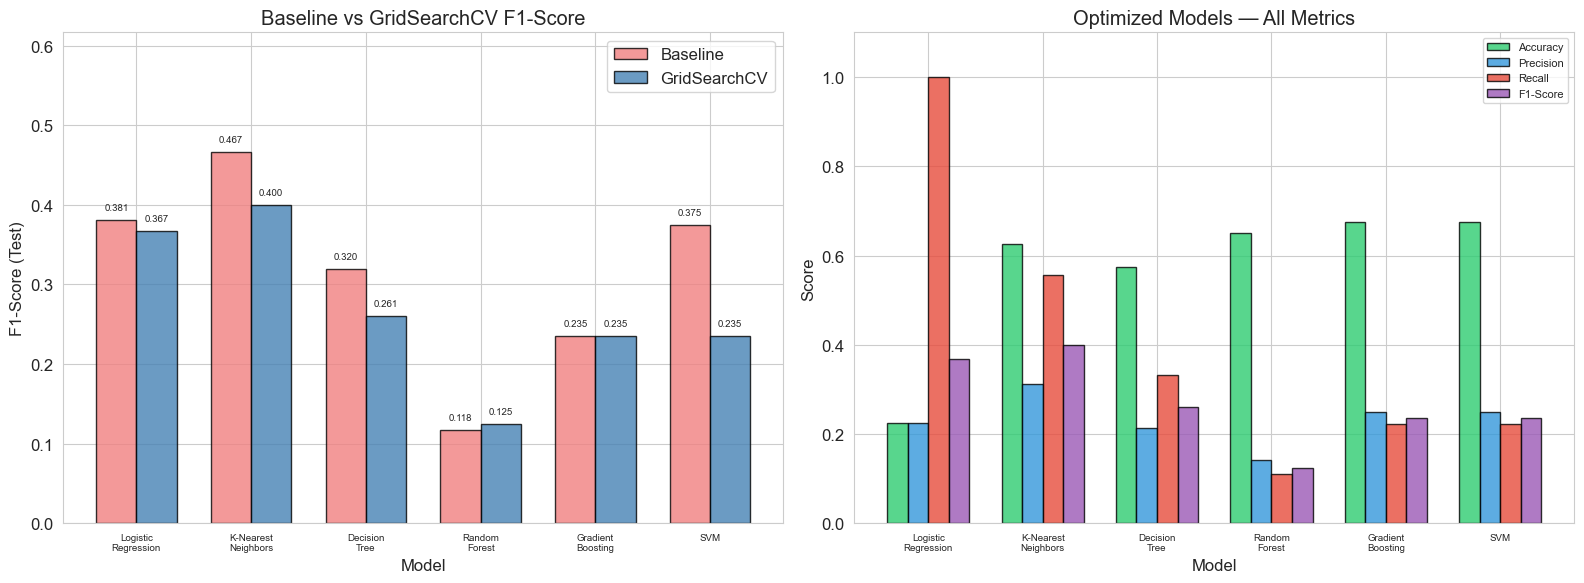

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names_short = [n.replace(' ', '\n') for n in best_models]
x = np.arange(len(best_models))
width = 0.35

# Left: Before vs After F1
bars1 = axes[0].bar(x - width/2, list(before_f1.values()), width,
                    label='Baseline', color='lightcoral', alpha=0.8, edgecolor='black')
bars2 = axes[0].bar(x + width/2, list(after_f1.values()),  width,
                    label='GridSearchCV', color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('F1-Score (Test)')
axes[0].set_title('Baseline vs GridSearchCV F1-Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names_short, fontsize=7)
axes[0].legend()
axes[0].set_ylim(0, max(max(after_f1.values()), max(before_f1.values())) + 0.15)
for bar in list(bars1) + list(bars2):
    if bar.get_height() > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

# Right: All metrics for optimized models
metric_keys   = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
bar_width = 0.18
metric_colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

for i, (key, label) in enumerate(zip(metric_keys, metric_labels)):
    vals = [after_metrics[n][key] for n in best_models]
    axes[1].bar(x + i * bar_width - 1.5 * bar_width, vals, bar_width,
                label=label, color=metric_colors[i], alpha=0.8, edgecolor='black')

axes[1].set_xlabel('Model')
axes[1].set_ylabel('Score')
axes[1].set_title('Optimized Models — All Metrics')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names_short, fontsize=7)
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

---
## 12. Feature Importance (Random Forest)

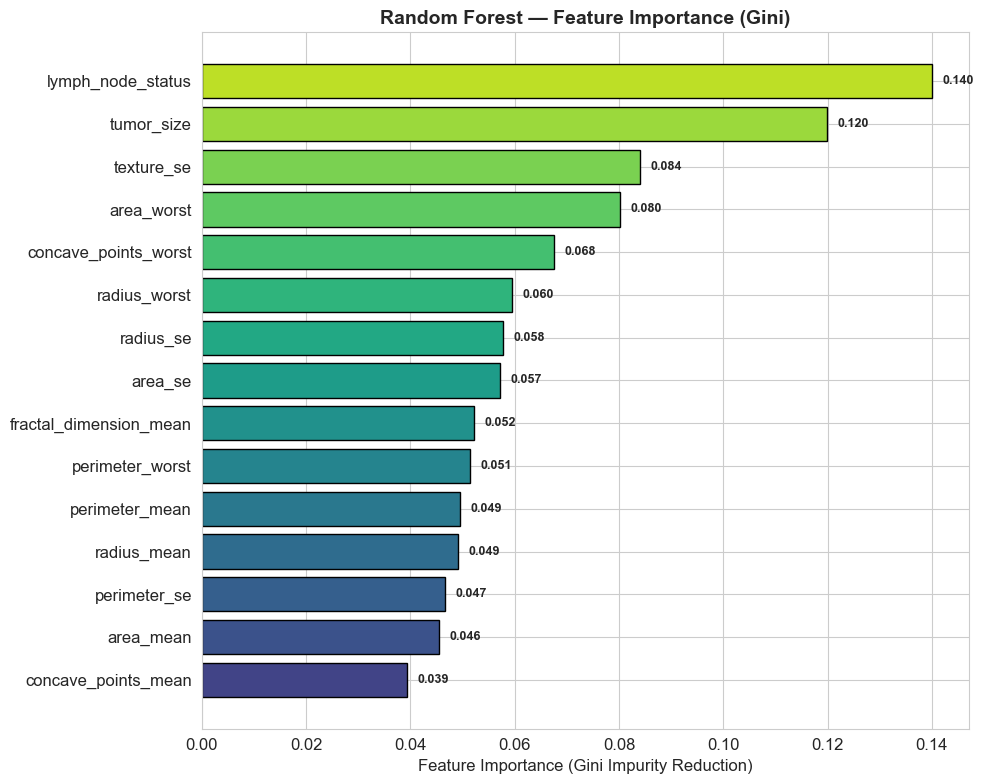


Feature Importance Ranking (Random Forest, Gini):
  lymph_node_status              0.1401 ##############
  tumor_size                     0.1199 ###########
  texture_se                     0.0841 ########
  area_worst                     0.0802 ########
  concave_points_worst           0.0676 ######
  radius_worst                   0.0596 #####
  radius_se                      0.0577 #####
  area_se                        0.0572 #####
  fractal_dimension_mean         0.0522 #####
  perimeter_worst                0.0514 #####
  perimeter_mean                 0.0495 ####
  radius_mean                    0.0492 ####
  perimeter_se                   0.0467 ####
  area_mean                      0.0456 ####
  concave_points_mean            0.0393 ###


In [34]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': top_features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(importance_df))),
               edgecolor='black')
ax.set_title('Random Forest — Feature Importance (Gini)', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance (Gini Impurity Reduction)')
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2.,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking (Random Forest, Gini):")
for i, row in importance_df.sort_values('Importance', ascending=False).iterrows():
    bar_vis = '#' * int(row['Importance'] * 100)
    print(f"  {row['Feature']:<30s} {row['Importance']:.4f} {bar_vis}")

**Feature importance results:**

| Rank | Feature | Importance |
|---|---|---|
| 1 | `lymph_node_status` | 0.140 |
| 2 | `tumor_size` | 0.120 |
| 3 | `texture_se` | 0.084 |
| 4 | `area_worst` | 0.080 |
| 5 | `concave_points_worst` | 0.068 |

**Lymph node status** and **tumor size** are the two most important features — fully consistent with established breast cancer prognostic knowledge. These clinical variables are known to be among the strongest predictors of recurrence in standard staging (TNM classification).

---
## 13. Discussion & Conclusions

### Summary

This analysis applied a comprehensive ML pipeline to classify breast cancer recurrence using the WPBC dataset (198 patients). Six classifiers were evaluated under baseline and optimized settings.

### Preprocessing Pipeline
1. `lymph_node_status`: 4 missing values imputed with median (~2% of data)
2. `time` removed — data leakage confirmed (correlation −0.35 with outcome; mean follow-up N=53.5 mo vs R=25.1 mo)
3. SMOTE applied to training set only (158→240, balanced 1:1); test set untouched (40 samples)
4. ANOVA F-test selected top 15 features; dimensionality reduced from 32 → 15

### Key Results

**Best test F1:** KNN (0.467) — highest recall for recurrence class (0.778), meaning 7 out of 9 true recurrence cases detected  
**Best AUC:** Logistic Regression (0.749) — most stable threshold-independent discriminator  
**Most reliable generalizer:** Logistic Regression (overfitting gap = 0.258, lowest of all models)

### Overfitting as the Central Challenge

| Model | Train F1 | Test F1 | Gap |
|---|---|---|---|
| Random Forest | 1.000 | 0.118 | 0.882 |
| Gradient Boosting | 1.000 | 0.235 | 0.765 |
| Decision Tree | 0.890 | 0.320 | 0.570 |
| SVM | 0.740 | 0.375 | 0.365 |
| KNN | 0.816 | 0.467 | 0.350 |
| **Logistic Regression** | **0.639** | **0.381** | **0.258** |

Ensemble methods with perfect training recall collapse on the test set — a consequence of high-variance learning from only 198 samples. **GridSearchCV did not reliably improve test performance**, confirming the challenge is structural (small dataset) rather than a tuning problem.

### Limitations

| Factor | Impact |
|---|---|
| 198 total samples | Insufficient for robust generalization |
| 40-sample test set | One prediction flip = 2.5% metric shift |
| 3.21:1 class imbalance | Minority class prediction inherently hard |
| SMOTE synthetic data | May inflate apparent training diversity |

### Recommendations for Future Work

1. **Nested cross-validation** — more reliable performance estimation with small N
2. **Bayesian hyperparameter optimization** — more efficient than exhaustive grid search
3. **Transfer learning / external data** — incorporate additional prognostic datasets
4. **Calibrated probabilities** — apply Platt scaling or isotonic regression for clinical decision support
5. **Explainability** — SHAP values for per-patient feature attribution

### References

- Wolberg, W. H., Street, W. N., & Mangasarian, O. L. (1995). Machine learning techniques to diagnose breast cancer from image-processed nuclear features of fine needle aspirates. *Cancer Letters*, 77, 163–171.
- UCI Machine Learning Repository. (1995). Breast Cancer Wisconsin (Prognostic). https://archive.ics.uci.edu/dataset/16/breast+cancer+wisconsin+prognostic
- Chawla, N. V., et al. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *JMLR*, 16, 321–357.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.